# Comprehensive Retail eCommerce Data Analysis

## Final Internship Project

### Project Objective
The objective of this project is to integrate multiple eCommerce data
analytics techniques into a comprehensive end-to-end analytical framework.

The project combines:

- Data Analytics Strategy
- Customer Segmentation and Behavioral Analysis
- Sales Trend Forecasting
- Website Analytics and Conversion Rate Optimization
- Pricing Strategy A/B Testing
- Integrated Business Insights and Recommendations

### Final Analytical Flow

Data Collection & Strategy
↓
Customer Behavior Analysis
↓
Sales Forecasting
↓
Website Performance Analysis
↓
Pricing Experimentation
↓
Integrated Business Insights
↓
Strategic Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Final eCommerce Analytics Project environment ready!")

Final eCommerce Analytics Project environment ready!


In [2]:
# Final integrated eCommerce dataset

n_customers = 6000

customer_id = np.arange(1, n_customers + 1)

traffic_source = np.random.choice(
    ['Organic Search', 'Paid Ads', 'Social Media', 'Email', 'Direct'],
    size=n_customers,
    p=[0.30, 0.22, 0.18, 0.12, 0.18]
)

device = np.random.choice(
    ['Mobile', 'Desktop', 'Tablet'],
    size=n_customers,
    p=[0.60, 0.33, 0.07]
)

customer_segment = np.random.choice(
    ['High Value', 'Regular', 'Occasional', 'At Risk'],
    size=n_customers,
    p=[0.18, 0.42, 0.25, 0.15]
)

pricing_group = np.random.choice(
    ['Control', 'Discount', 'Premium'],
    size=n_customers,
    p=[0.34, 0.33, 0.33]
)

price_map = {
    'Control': 1000,
    'Discount': 900,
    'Premium': 1100
}

price_shown = pd.Series(pricing_group).map(price_map).values

session_duration = np.random.gamma(
    shape=2.4,
    scale=80,
    size=n_customers
)

pages_viewed = np.maximum(
    1,
    np.random.poisson(
        np.clip(session_duration / 70, 1, 8)
    )
)

bounce_probability = np.clip(
    0.60
    - session_duration / 1300
    - pages_viewed * 0.035,
    0.08,
    0.80
)

bounce = np.random.binomial(
    1,
    bounce_probability
)

# Base conversion by pricing strategy
base_conversion = np.select(
    [
        pricing_group == 'Control',
        pricing_group == 'Discount',
        pricing_group == 'Premium'
    ],
    [
        0.065,
        0.078,
        0.055
    ]
)

# Adjust by customer segment
segment_adjustment = np.select(
    [
        customer_segment == 'High Value',
        customer_segment == 'Regular',
        customer_segment == 'Occasional',
        customer_segment == 'At Risk'
    ],
    [
        0.030,
        0.010,
        -0.005,
        -0.020
    ]
)

# Engagement adjustment
engagement_adjustment = np.clip(
    session_duration / 10000
    + pages_viewed / 500,
    0,
    0.04
)

final_conversion_probability = np.clip(
    base_conversion
    + segment_adjustment
    + engagement_adjustment,
    0.01,
    0.25
)

purchase = np.random.binomial(
    1,
    final_conversion_probability
)

quantity = np.where(
    purchase == 1,
    np.random.choice(
        [1, 2, 3],
        size=n_customers,
        p=[0.72, 0.23, 0.05]
    ),
    0
)

revenue = price_shown * quantity

unit_cost = 600

profit = np.where(
    purchase == 1,
    (price_shown - unit_cost) * quantity,
    0
)

master_df = pd.DataFrame({
    'Customer_ID': customer_id,
    'Customer_Segment': customer_segment,
    'Traffic_Source': traffic_source,
    'Device': device,
    'Pricing_Group': pricing_group,
    'Price_Shown': price_shown,
    'Session_Duration_Seconds': session_duration.round(2),
    'Pages_Viewed': pages_viewed,
    'Bounce': bounce,
    'Purchase': purchase,
    'Quantity': quantity,
    'Revenue': revenue,
    'Estimated_Profit': profit
})

print("✅ Integrated dataset created successfully!")
print("Shape:", master_df.shape)

display(master_df.head())

✅ Integrated dataset created successfully!
Shape: (6000, 13)


,Customer_ID,Customer_Segment,Traffic_Source,Device,Pricing_Group,Price_Shown,Session_Duration_Seconds,Pages_Viewed,Bounce,Purchase,Quantity,Revenue,Estimated_Profit
0,1,Occasional,Paid Ads,Desktop,Discount,900,129.21,1,1,0,0,0,0
1,2,High Value,Direct,Mobile,Discount,900,505.48,4,0,0,0,0,0
2,3,Regular,Email,Desktop,Discount,900,159.74,1,0,0,0,0,0
3,4,Occasional,Social Media,Desktop,Premium,1100,207.94,6,0,1,1,1100,500
4,5,Regular,Organic Search,Mobile,Premium,1100,110.57,1,1,0,0,0,0


In [3]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               6000 non-null   int64  
 1   Customer_Segment          6000 non-null   object 
 2   Traffic_Source            6000 non-null   object 
 3   Device                    6000 non-null   object 
 4   Pricing_Group             6000 non-null   object 
 5   Price_Shown               6000 non-null   int64  
 6   Session_Duration_Seconds  6000 non-null   float64
 7   Pages_Viewed              6000 non-null   int64  
 8   Bounce                    6000 non-null   int64  
 9   Purchase                  6000 non-null   int64  
 10  Quantity                  6000 non-null   int64  
 11  Revenue                   6000 non-null   int64  
 12  Estimated_Profit          6000 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 609.5+ KB


In [4]:
master_df.describe()

,Customer_ID,Price_Shown,Session_Duration_Seconds,Pages_Viewed,Bounce,Purchase,Quantity,Revenue,Estimated_Profit
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,1002.300000,192.012137,2.901000,0.358667,0.085833,0.115833,115.116667,45.616667
std,1732.195139,82.092427,123.781783,2.180212,0.479649,0.280141,0.413656,414.099504,168.242396
min,1.000000,900.000000,2.170000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1500.750000,900.000000,99.670000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3000.500000,1000.000000,167.450000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4500.250000,1100.000000,255.477500,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,6000.000000,1100.000000,1057.000000,17.000000,1.000000,1.000000,3.000000,3300.000000,1500.000000


In [5]:
print(master_df.isnull().sum())

Customer_ID                 0
Customer_Segment            0
Traffic_Source              0
Device                      0
Pricing_Group               0
Price_Shown                 0
Session_Duration_Seconds    0
Pages_Viewed                0
Bounce                      0
Purchase                    0
Quantity                    0
Revenue                     0
Estimated_Profit            0
dtype: int64


In [6]:
master_df.to_csv(
    'final_ecommerce_integrated_dataset.csv',
    index=False
)

print("✅ Final integrated dataset saved successfully!")

✅ Final integrated dataset saved successfully!


In [7]:
total_customers = len(master_df)

total_purchases = master_df['Purchase'].sum()

overall_conversion_rate = (
    total_purchases / total_customers
) * 100

overall_bounce_rate = (
    master_df['Bounce'].mean()
) * 100

avg_session_duration = (
    master_df['Session_Duration_Seconds'].mean()
)

avg_pages_viewed = (
    master_df['Pages_Viewed'].mean()
)

total_revenue = (
    master_df['Revenue'].sum()
)

total_profit = (
    master_df['Estimated_Profit'].sum()
)

revenue_per_customer = (
    total_revenue / total_customers
)

profit_per_customer = (
    total_profit / total_customers
)

avg_order_value = (
    total_revenue / total_purchases
)

print("✅ Overall KPIs calculated successfully!")

✅ Overall KPIs calculated successfully!


In [8]:
final_kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Customers / Sessions',
        'Total Purchases',
        'Overall Conversion Rate',
        'Overall Bounce Rate',
        'Average Session Duration',
        'Average Pages Viewed',
        'Average Order Value',
        'Revenue per Customer',
        'Profit per Customer',
        'Total Revenue',
        'Total Estimated Profit'
    ],

    'Value': [
        f'{total_customers:,}',
        f'{total_purchases:,}',
        f'{overall_conversion_rate:.2f}%',
        f'{overall_bounce_rate:.2f}%',
        f'{avg_session_duration:.2f} sec',
        f'{avg_pages_viewed:.2f}',
        f'₹{avg_order_value:,.2f}',
        f'₹{revenue_per_customer:,.2f}',
        f'₹{profit_per_customer:,.2f}',
        f'₹{total_revenue:,.2f}',
        f'₹{total_profit:,.2f}'
    ]
})

display(final_kpi_summary)

,KPI,Value
0,Total Customers / Sessions,"6,000"
1,Total Purchases,515
2,Overall Conversion Rate,8.58%
3,Overall Bounce Rate,35.87%
4,Average Session Duration,192.01 sec
5,Average Pages Viewed,2.90
6,Average Order Value,"₹1,341.17"
7,Revenue per Customer,₹115.12
8,Profit per Customer,₹45.62
9,Total Revenue,"₹690,700.00"


In [9]:
segment_summary = master_df.groupby(
    'Customer_Segment'
).agg(
    Customers=('Customer_ID', 'count'),
    Purchases=('Purchase', 'sum'),
    Conversion_Rate=('Purchase', 'mean'),
    Avg_Session_Duration=(
        'Session_Duration_Seconds',
        'mean'
    ),
    Avg_Pages_Viewed=('Pages_Viewed', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Estimated_Profit', 'sum')
).reset_index()

segment_summary['Conversion_Rate'] *= 100

segment_summary['Revenue_Per_Customer'] = (
    segment_summary['Total_Revenue']
    / segment_summary['Customers']
)

segment_summary['Profit_Per_Customer'] = (
    segment_summary['Total_Profit']
    / segment_summary['Customers']
)

segment_summary = segment_summary.round(2)

display(segment_summary)

,Customer_Segment,Customers,Purchases,Conversion_Rate,Avg_Session_Duration,Avg_Pages_Viewed,Total_Revenue,Total_Profit,Revenue_Per_Customer,Profit_Per_Customer
0,At Risk,907,41,4.52,197.24,2.97,58100,23300,64.06,25.69
1,High Value,1056,100,9.47,195.63,2.97,127000,50200,120.27,47.54
2,Occasional,1489,122,8.19,194.37,2.95,165700,64900,111.28,43.59
3,Regular,2548,252,9.89,187.27,2.82,339900,135300,133.40,53.10


In [10]:
traffic_summary = master_df.groupby(
    'Traffic_Source'
).agg(
    Sessions=('Customer_ID', 'count'),
    Bounce_Rate=('Bounce', 'mean'),
    Conversion_Rate=('Purchase', 'mean'),
    Avg_Session_Duration=(
        'Session_Duration_Seconds',
        'mean'
    ),
    Revenue=('Revenue', 'sum'),
    Profit=('Estimated_Profit', 'sum')
).reset_index()

traffic_summary['Bounce_Rate'] *= 100
traffic_summary['Conversion_Rate'] *= 100

traffic_summary['Revenue_Per_Session'] = (
    traffic_summary['Revenue']
    / traffic_summary['Sessions']
)

traffic_summary = traffic_summary.round(2)

display(traffic_summary)

,Traffic_Source,Sessions,Bounce_Rate,Conversion_Rate,Avg_Session_Duration,Revenue,Profit,Revenue_Per_Session
0,Direct,1066,37.43,8.35,194.33,115400,45800,108.26
1,Email,696,34.91,8.48,190.68,78000,31200,112.07
2,Organic Search,1832,35.26,7.91,190.55,203800,80200,111.24
3,Paid Ads,1306,35.83,9.72,190.76,165200,65000,126.49
4,Social Media,1100,36.00,8.64,194.53,128300,51500,116.64


In [11]:
device_summary = master_df.groupby(
    'Device'
).agg(
    Sessions=('Customer_ID', 'count'),
    Bounce_Rate=('Bounce', 'mean'),
    Conversion_Rate=('Purchase', 'mean'),
    Avg_Session_Duration=(
        'Session_Duration_Seconds',
        'mean'
    ),
    Revenue=('Revenue', 'sum'),
    Profit=('Estimated_Profit', 'sum')
).reset_index()

device_summary['Bounce_Rate'] *= 100
device_summary['Conversion_Rate'] *= 100

device_summary['Revenue_Per_Session'] = (
    device_summary['Revenue']
    / device_summary['Sessions']
)

device_summary = device_summary.round(2)

display(device_summary)

,Device,Sessions,Bounce_Rate,Conversion_Rate,Avg_Session_Duration,Revenue,Profit,Revenue_Per_Session
0,Desktop,1909,37.09,8.17,192.66,209600,84200,109.80
1,Mobile,3685,35.28,8.71,191.05,427700,168500,116.07
2,Tablet,406,35.47,9.36,197.67,53400,21000,131.53


In [12]:
pricing_summary_final = master_df.groupby(
    'Pricing_Group'
).agg(
    Visitors=('Customer_ID', 'count'),
    Purchases=('Purchase', 'sum'),
    Conversion_Rate=('Purchase', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Estimated_Profit', 'sum')
).reset_index()

pricing_summary_final['Conversion_Rate'] *= 100

pricing_summary_final['Revenue_Per_Visitor'] = (
    pricing_summary_final['Total_Revenue']
    / pricing_summary_final['Visitors']
)

pricing_summary_final['Profit_Per_Visitor'] = (
    pricing_summary_final['Total_Profit']
    / pricing_summary_final['Visitors']
)

pricing_summary_final = pricing_summary_final.round(2)

display(pricing_summary_final)

,Pricing_Group,Visitors,Purchases,Conversion_Rate,Total_Revenue,Total_Profit,Revenue_Per_Visitor,Profit_Per_Visitor
0,Control,1954,172,8.80,220000,88000,112.59,45.04
1,Discount,1954,192,9.83,233100,77700,119.29,39.76
2,Premium,2092,151,7.22,237600,108000,113.58,51.63


In [13]:
best_segment = segment_summary.loc[
    segment_summary['Revenue_Per_Customer'].idxmax()
]

best_traffic = traffic_summary.loc[
    traffic_summary['Conversion_Rate'].idxmax()
]

best_device = device_summary.loc[
    device_summary['Conversion_Rate'].idxmax()
]

best_pricing = pricing_summary_final.loc[
    pricing_summary_final['Profit_Per_Visitor'].idxmax()
]

print("===== KEY PERFORMANCE HIGHLIGHTS =====\n")

print(
    "Best Customer Segment:",
    best_segment['Customer_Segment']
)

print(
    "Best Traffic Source:",
    best_traffic['Traffic_Source']
)

print(
    "Best Converting Device:",
    best_device['Device']
)

print(
    "Best Pricing Strategy by Profit/Visitor:",
    best_pricing['Pricing_Group']
)

===== KEY PERFORMANCE HIGHLIGHTS =====

Best Customer Segment: Regular
Best Traffic Source: Paid Ads
Best Converting Device: Tablet
Best Pricing Strategy by Profit/Visitor: Premium


In [14]:
final_kpi_summary.to_csv(
    'final_kpi_summary.csv',
    index=False
)

segment_summary.to_csv(
    'final_customer_segment_summary.csv',
    index=False
)

traffic_summary.to_csv(
    'final_traffic_source_summary.csv',
    index=False
)

device_summary.to_csv(
    'final_device_summary.csv',
    index=False
)

pricing_summary_final.to_csv(
    'final_pricing_summary.csv',
    index=False
)

print("✅ Final KPI tables saved successfully!")

✅ Final KPI tables saved successfully!


## Customer Segmentation and Behavioral Analysis

Customer segmentation helps an eCommerce business understand how different
groups of customers behave and contribute to business performance.

This analysis compares High Value, Regular, Occasional, and At Risk customers
using conversion rate, revenue per customer, engagement, and profitability.

The objective is to identify valuable customer groups and develop targeted
retention, acquisition, and marketing strategies.

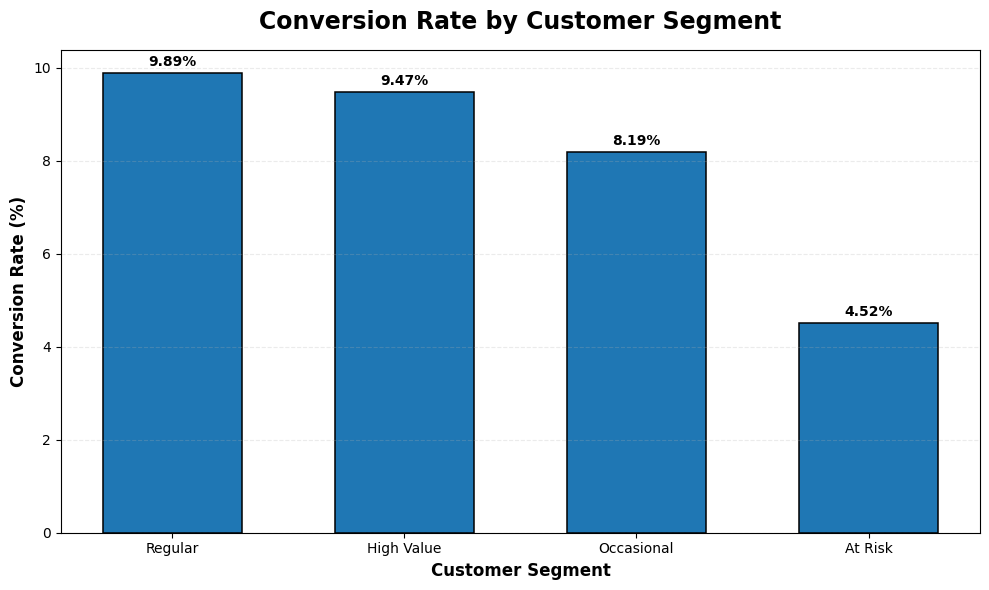

In [15]:
plt.figure(figsize=(10, 6))

sorted_segments = segment_summary.sort_values(
    'Conversion_Rate',
    ascending=False
)

bars = plt.bar(
    sorted_segments['Customer_Segment'],
    sorted_segments['Conversion_Rate'],
    edgecolor='black',
    linewidth=1.1,
    width=0.6
)

plt.title(
    'Conversion Rate by Customer Segment',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Customer Segment',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Conversion Rate (%)',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.15,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    '01_customer_segment_conversion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

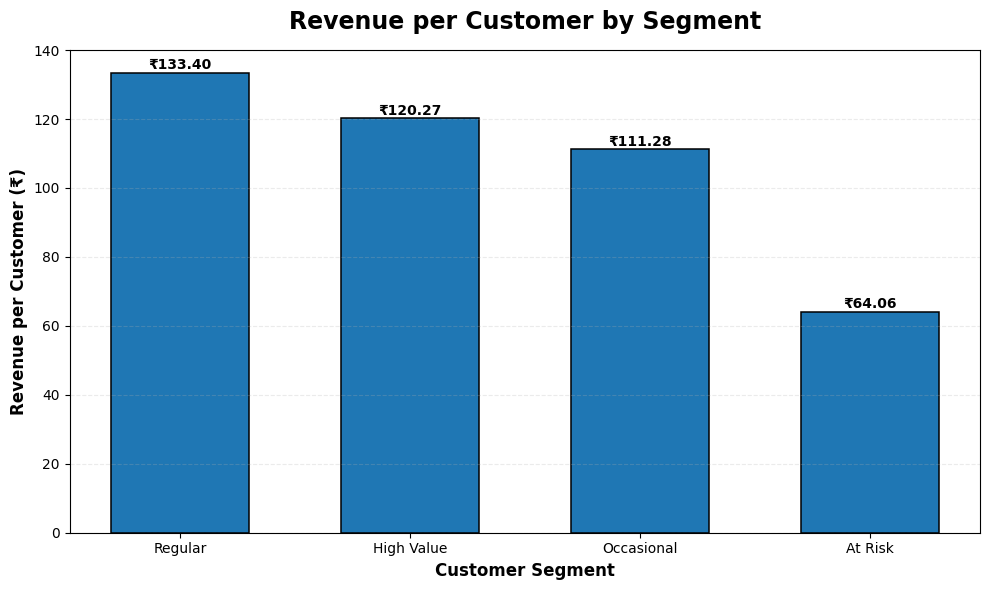

In [16]:
plt.figure(figsize=(10, 6))

sorted_revenue = segment_summary.sort_values(
    'Revenue_Per_Customer',
    ascending=False
)

bars = plt.bar(
    sorted_revenue['Customer_Segment'],
    sorted_revenue['Revenue_Per_Customer'],
    edgecolor='black',
    linewidth=1.1,
    width=0.6
)

plt.title(
    'Revenue per Customer by Segment',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Customer Segment',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Revenue per Customer (₹)',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'₹{value:.2f}',
        ha='center',
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    '02_customer_segment_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [17]:
engagement_summary = master_df.groupby(
    'Customer_Segment'
).agg(
    Avg_Session_Duration=(
        'Session_Duration_Seconds',
        'mean'
    ),
    Avg_Pages_Viewed=(
        'Pages_Viewed',
        'mean'
    )
).reset_index()

engagement_summary = engagement_summary.round(2)

display(engagement_summary)

,Customer_Segment,Avg_Session_Duration,Avg_Pages_Viewed
0,At Risk,197.24,2.97
1,High Value,195.63,2.97
2,Occasional,194.37,2.95
3,Regular,187.27,2.82


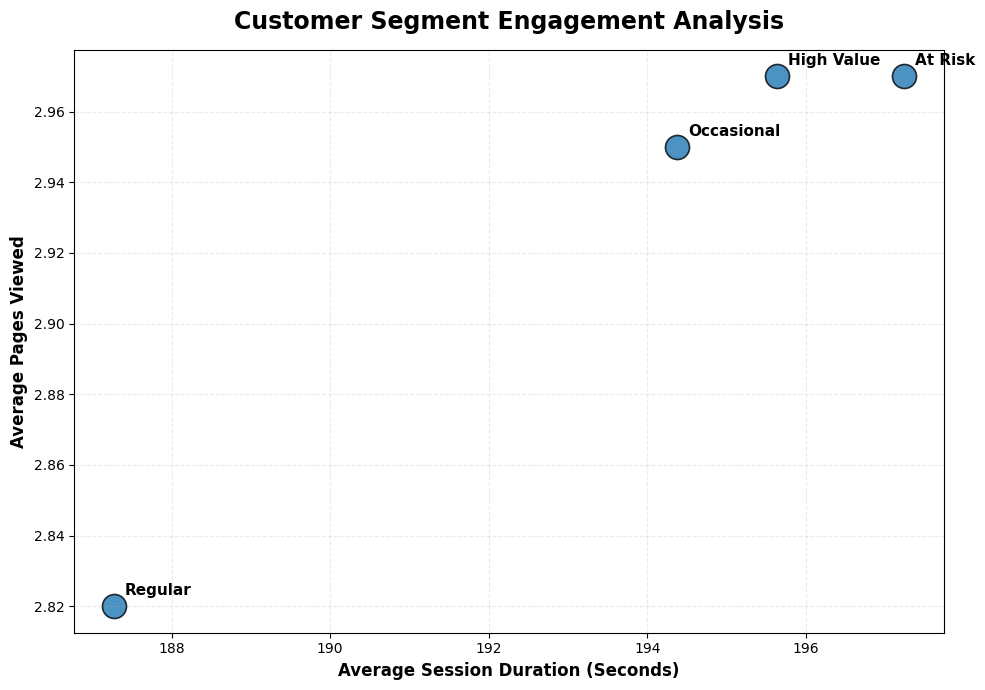

In [18]:
plt.figure(figsize=(10, 7))

plt.scatter(
    engagement_summary['Avg_Session_Duration'],
    engagement_summary['Avg_Pages_Viewed'],
    s=300,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.8
)

for _, row in engagement_summary.iterrows():

    plt.annotate(
        row['Customer_Segment'],
        (
            row['Avg_Session_Duration'],
            row['Avg_Pages_Viewed']
        ),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Customer Segment Engagement Analysis',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Average Session Duration (Seconds)',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Average Pages Viewed',
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    '03_customer_segment_engagement.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [19]:
highest_conversion_segment = segment_summary.loc[
    segment_summary['Conversion_Rate'].idxmax()
]

highest_revenue_segment = segment_summary.loc[
    segment_summary['Revenue_Per_Customer'].idxmax()
]

highest_profit_segment = segment_summary.loc[
    segment_summary['Profit_Per_Customer'].idxmax()
]

print("===== CUSTOMER SEGMENT INSIGHTS =====\n")

print(
    f"Highest Conversion: "
    f"{highest_conversion_segment['Customer_Segment']} "
    f"({highest_conversion_segment['Conversion_Rate']:.2f}%)"
)

print(
    f"Highest Revenue per Customer: "
    f"{highest_revenue_segment['Customer_Segment']} "
    f"(₹{highest_revenue_segment['Revenue_Per_Customer']:.2f})"
)

print(
    f"Highest Profit per Customer: "
    f"{highest_profit_segment['Customer_Segment']} "
    f"(₹{highest_profit_segment['Profit_Per_Customer']:.2f})"
)

===== CUSTOMER SEGMENT INSIGHTS =====

Highest Conversion: Regular (9.89%)
Highest Revenue per Customer: Regular (₹133.40)
Highest Profit per Customer: Regular (₹53.10)


In [20]:
engagement_summary.to_csv(
    'final_customer_engagement_summary.csv',
    index=False
)

print("✅ Customer segmentation analysis saved successfully!")

✅ Customer segmentation analysis saved successfully!


In [21]:
# Create simulated monthly sales trend for 18 months

months = pd.date_range(
    start='2025-01-01',
    periods=18,
    freq='MS'
)

base_sales = np.linspace(
    450000,
    700000,
    18
)

seasonality = np.array([
    0, 20000, 35000, 10000, 25000, 40000,
    15000, 30000, 50000, 45000, 80000, 120000,
    10000, 30000, 45000, 25000, 40000, 90000
])

noise = np.random.normal(
    0,
    18000,
    18
)

monthly_revenue = (
    base_sales
    + seasonality
    + noise
)

sales_trend_df = pd.DataFrame({
    'Month': months,
    'Revenue': monthly_revenue.round(2)
})

display(sales_trend_df)

,Month,Revenue
0,2025-01-01,416904.66
1,2025-02-01,455581.65
2,2025-03-01,525473.89
3,2025-04-01,482719.33
4,2025-05-01,552635.49
5,2025-06-01,581390.27
6,2025-07-01,560290.95
7,2025-08-01,575615.04
8,2025-09-01,620229.17
9,2025-10-01,616298.74


In [22]:
sales_trend_df['Moving_Average_3M'] = (
    sales_trend_df['Revenue']
    .rolling(window=3)
    .mean()
)

display(sales_trend_df)

,Month,Revenue,Moving_Average_3M
0,2025-01-01,416904.66,NaN
1,2025-02-01,455581.65,NaN
2,2025-03-01,525473.89,465986.733333
3,2025-04-01,482719.33,487924.956667
4,2025-05-01,552635.49,520276.236667
5,2025-06-01,581390.27,538915.030000
6,2025-07-01,560290.95,564772.236667
7,2025-08-01,575615.04,572432.086667
8,2025-09-01,620229.17,585378.386667
9,2025-10-01,616298.74,604047.650000


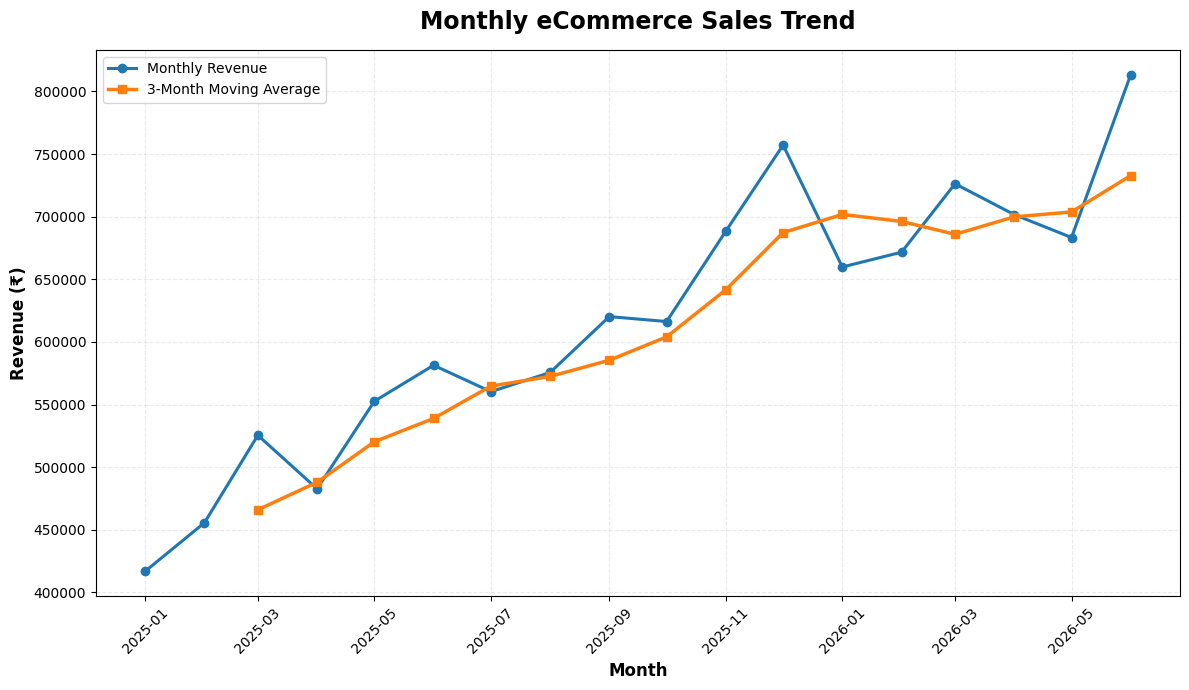

In [23]:
plt.figure(figsize=(12, 7))

plt.plot(
    sales_trend_df['Month'],
    sales_trend_df['Revenue'],
    marker='o',
    linewidth=2.2,
    label='Monthly Revenue'
)

plt.plot(
    sales_trend_df['Month'],
    sales_trend_df['Moving_Average_3M'],
    marker='s',
    linewidth=2.5,
    label='3-Month Moving Average'
)

plt.title(
    'Monthly eCommerce Sales Trend',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Month',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Revenue (₹)',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(
    rotation=45
)

plt.grid(
    linestyle='--',
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    '04_monthly_sales_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [24]:
from sklearn.linear_model import LinearRegression

sales_trend_df['Time_Index'] = np.arange(
    len(sales_trend_df)
)

X = sales_trend_df[
    ['Time_Index']
]

y = sales_trend_df[
    'Revenue'
]

linear_model = LinearRegression()

linear_model.fit(
    X,
    y
)

sales_trend_df['Linear_Trend'] = (
    linear_model.predict(X)
)

print(
    "Linear Regression model trained successfully!"
)

Linear Regression model trained successfully!


In [25]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(
    sales_trend_df['Revenue'],
    trend='add',
    seasonal=None
).fit()

sales_trend_df['Exponential_Smoothing'] = (
    exp_model.fittedvalues
)

print(
    "Exponential Smoothing model fitted successfully!"
)

Exponential Smoothing model fitted successfully!


In [26]:
future_periods = 6

future_index = np.arange(
    len(sales_trend_df),
    len(sales_trend_df) + future_periods
)

future_linear = linear_model.predict(
    future_index.reshape(-1, 1)
)

future_exp = exp_model.forecast(
    future_periods
)

future_months = pd.date_range(
    start=sales_trend_df['Month'].max()
    + pd.offsets.MonthBegin(1),
    periods=future_periods,
    freq='MS'
)

future_forecast = pd.DataFrame({
    'Month': future_months,
    'Linear_Regression_Forecast': future_linear,
    'Exponential_Smoothing_Forecast': future_exp
})

future_forecast = future_forecast.round(2)

display(future_forecast)

,Month,Linear_Regression_Forecast,Exponential_Smoothing_Forecast
18,2026-07-01,793184.09,801633.19
19,2026-08-01,811829.08,821542.71
20,2026-09-01,830474.08,841452.23
21,2026-10-01,849119.08,861361.75
22,2026-11-01,867764.08,881271.27
23,2026-12-01,886409.08,901180.79


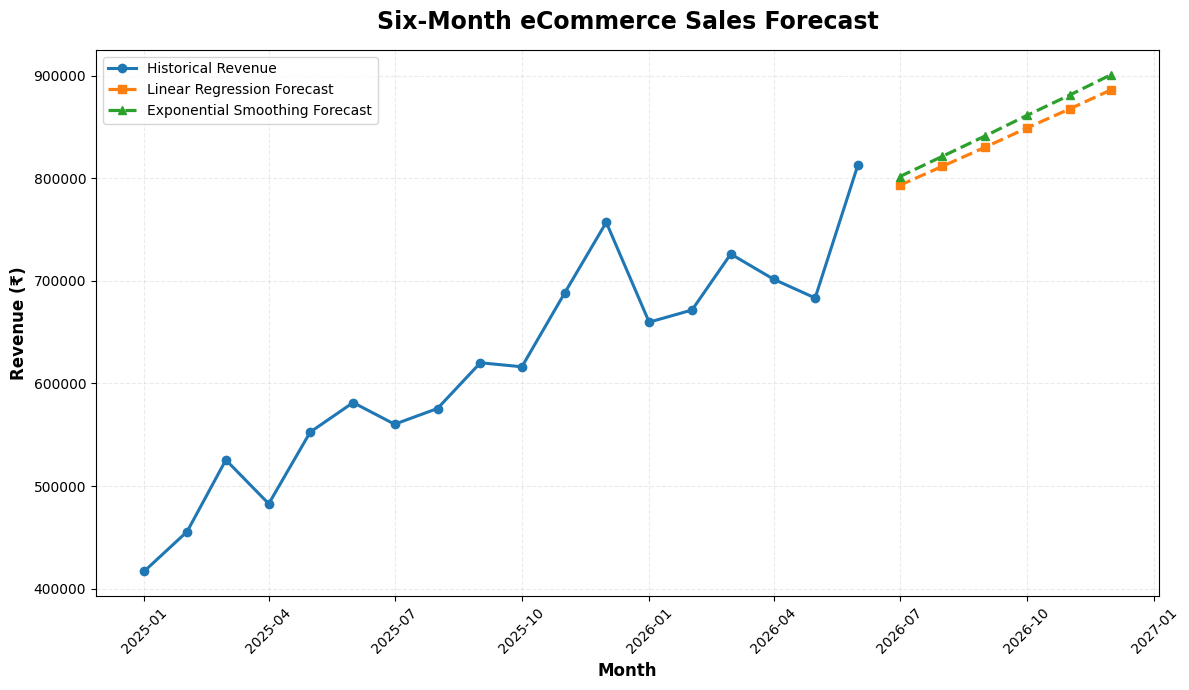

In [27]:
plt.figure(figsize=(12, 7))

plt.plot(
    sales_trend_df['Month'],
    sales_trend_df['Revenue'],
    marker='o',
    linewidth=2.2,
    label='Historical Revenue'
)

plt.plot(
    future_forecast['Month'],
    future_forecast['Linear_Regression_Forecast'],
    marker='s',
    linestyle='--',
    linewidth=2.3,
    label='Linear Regression Forecast'
)

plt.plot(
    future_forecast['Month'],
    future_forecast['Exponential_Smoothing_Forecast'],
    marker='^',
    linestyle='--',
    linewidth=2.3,
    label='Exponential Smoothing Forecast'
)

plt.title(
    'Six-Month eCommerce Sales Forecast',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Month',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Revenue (₹)',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.grid(
    linestyle='--',
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.savefig(
    '05_sales_forecast_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

valid_ma = sales_trend_df.dropna(
    subset=['Moving_Average_3M']
)

ma_mae = mean_absolute_error(
    valid_ma['Revenue'],
    valid_ma['Moving_Average_3M']
)

linear_mae = mean_absolute_error(
    sales_trend_df['Revenue'],
    sales_trend_df['Linear_Trend']
)

exp_mae = mean_absolute_error(
    sales_trend_df['Revenue'],
    sales_trend_df['Exponential_Smoothing']
)

forecast_method_summary = pd.DataFrame({
    'Method': [
        '3-Month Moving Average',
        'Linear Regression',
        'Exponential Smoothing'
    ],

    'MAE': [
        ma_mae,
        linear_mae,
        exp_mae
    ]
})

forecast_method_summary = (
    forecast_method_summary
    .sort_values('MAE')
    .round(2)
)

display(forecast_method_summary)

,Method,MAE
2,Exponential Smoothing,30366.71
1,Linear Regression,31184.20
0,3-Month Moving Average,32540.63


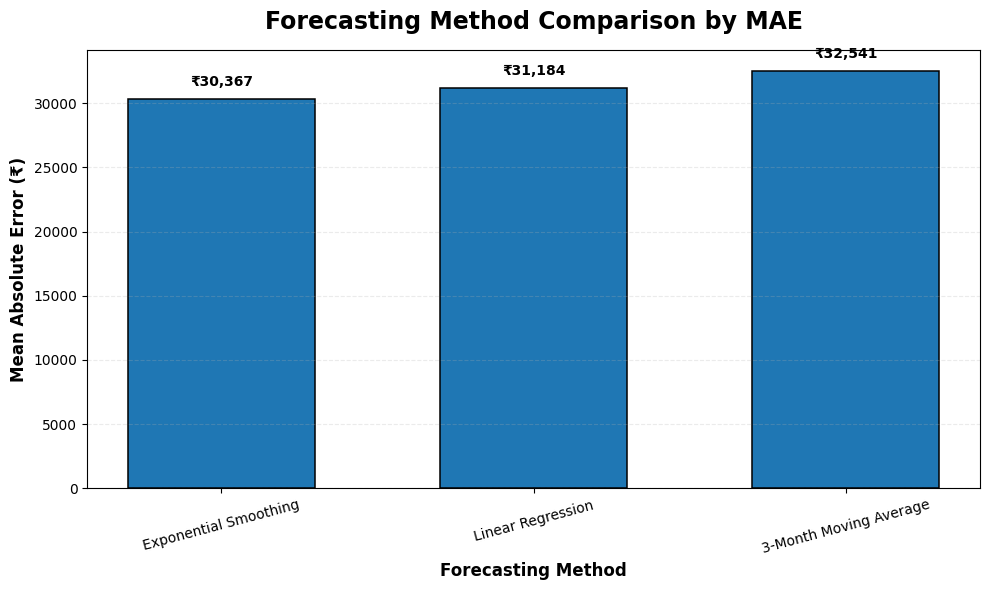

In [29]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    forecast_method_summary['Method'],
    forecast_method_summary['MAE'],
    edgecolor='black',
    linewidth=1.1,
    width=0.6
)

plt.title(
    'Forecasting Method Comparison by MAE',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Forecasting Method',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Mean Absolute Error (₹)',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(
    rotation=15
)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1000,
        f'₹{value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    '06_forecasting_model_mae.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
best_forecast_method = (
    forecast_method_summary.iloc[0]
)

print(
    "Best Forecasting Method:",
    best_forecast_method['Method']
)

print(
    f"Lowest MAE: "
    f"₹{best_forecast_method['MAE']:,.2f}"
)

Best Forecasting Method: Exponential Smoothing
Lowest MAE: ₹30,366.71


In [31]:
sales_trend_df.to_csv(
    'final_monthly_sales_analysis.csv',
    index=False
)

future_forecast.to_csv(
    'final_sales_forecast_6_months.csv',
    index=False
)

forecast_method_summary.to_csv(
    'final_forecasting_method_comparison.csv',
    index=False
)

print(
    "✅ Sales forecasting analysis saved successfully!"
)

✅ Sales forecasting analysis saved successfully!


In [32]:
funnel_summary = pd.DataFrame({
    'Stage': [
        'Website Sessions',
        'Engaged Sessions',
        'Purchases'
    ],
    'Users': [
        len(master_df),
        (master_df['Bounce'] == 0).sum(),
        master_df['Purchase'].sum()
    ]
})

funnel_summary['Stage_Conversion_Rate'] = (
    funnel_summary['Users']
    / funnel_summary['Users'].shift(1)
    * 100
)

funnel_summary.loc[0, 'Stage_Conversion_Rate'] = 100

funnel_summary['Drop_Off_Rate'] = (
    100 - funnel_summary['Stage_Conversion_Rate']
)

funnel_summary.loc[0, 'Drop_Off_Rate'] = 0

funnel_summary = funnel_summary.round(2)

display(funnel_summary)

,Stage,Users,Stage_Conversion_Rate,Drop_Off_Rate
0,Website Sessions,6000,100.00,0.00
1,Engaged Sessions,3848,64.13,35.87
2,Purchases,515,13.38,86.62


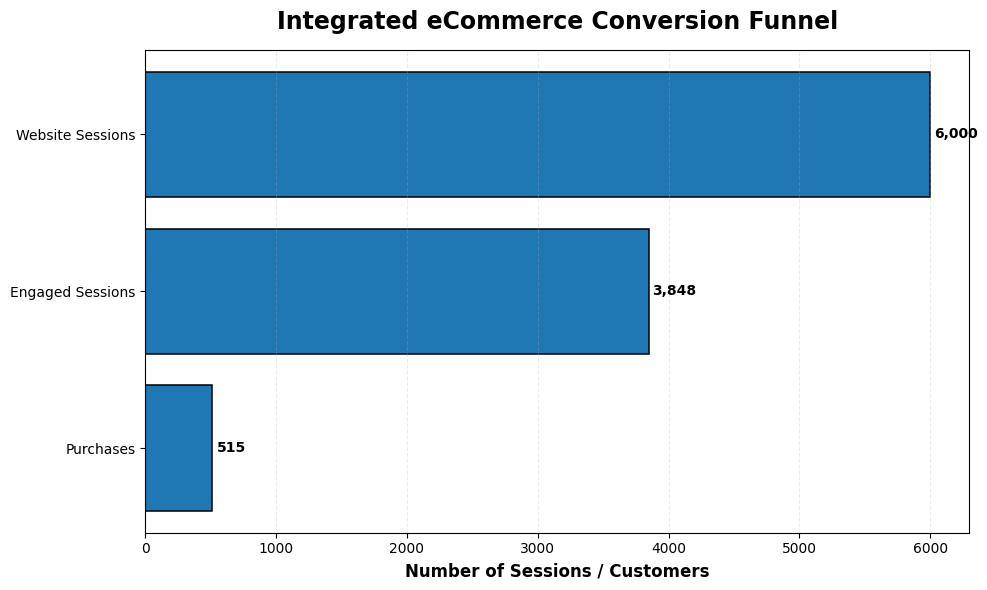

In [33]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    funnel_summary['Stage'],
    funnel_summary['Users'],
    edgecolor='black',
    linewidth=1.1
)

plt.title(
    'Integrated eCommerce Conversion Funnel',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Number of Sessions / Customers',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 30,
        bar.get_y() + bar.get_height()/2,
        f'{int(value):,}',
        va='center',
        fontweight='bold'
    )

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.tight_layout()

plt.savefig(
    '07_integrated_conversion_funnel.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

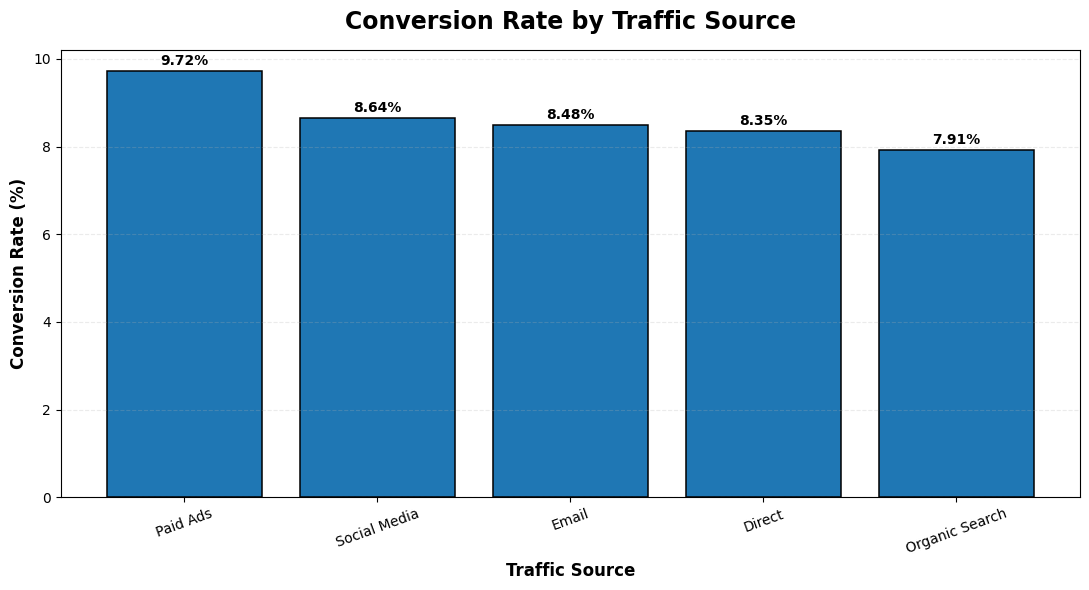

In [34]:
traffic_sorted = traffic_summary.sort_values(
    'Conversion_Rate',
    ascending=False
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    traffic_sorted['Traffic_Source'],
    traffic_sorted['Conversion_Rate'],
    edgecolor='black',
    linewidth=1.1
)

plt.title(
    'Conversion Rate by Traffic Source',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Traffic Source',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Conversion Rate (%)',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.15,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.xticks(rotation=20)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    '08_traffic_source_conversion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

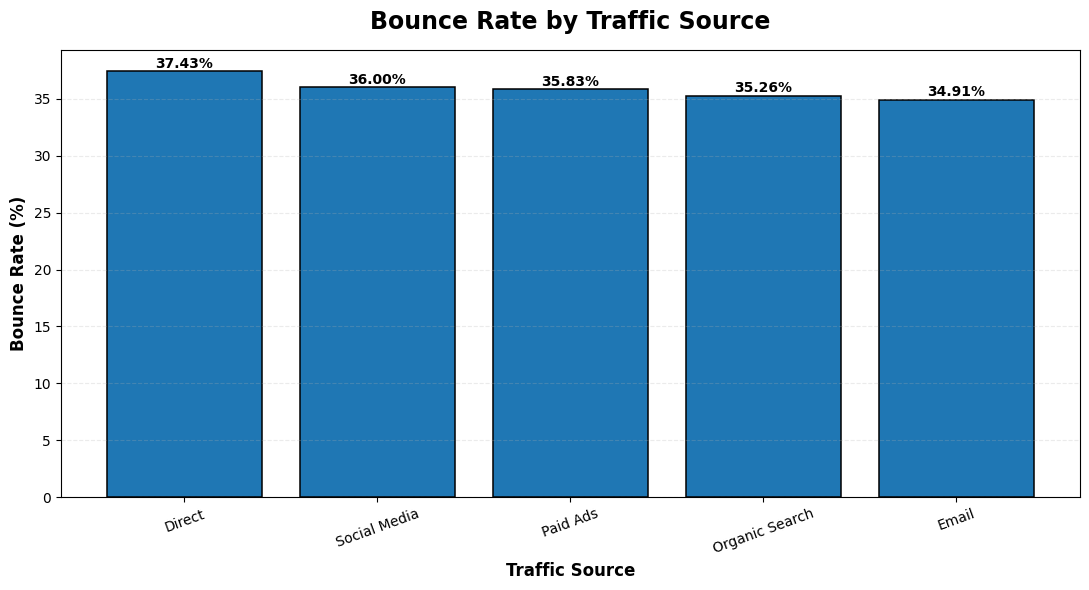

In [35]:
traffic_bounce = traffic_summary.sort_values(
    'Bounce_Rate',
    ascending=False
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    traffic_bounce['Traffic_Source'],
    traffic_bounce['Bounce_Rate'],
    edgecolor='black',
    linewidth=1.1
)

plt.title(
    'Bounce Rate by Traffic Source',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel('Traffic Source', fontsize=12, fontweight='bold')
plt.ylabel('Bounce Rate (%)', fontsize=12, fontweight='bold')

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.3,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()

plt.savefig(
    '09_traffic_source_bounce.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

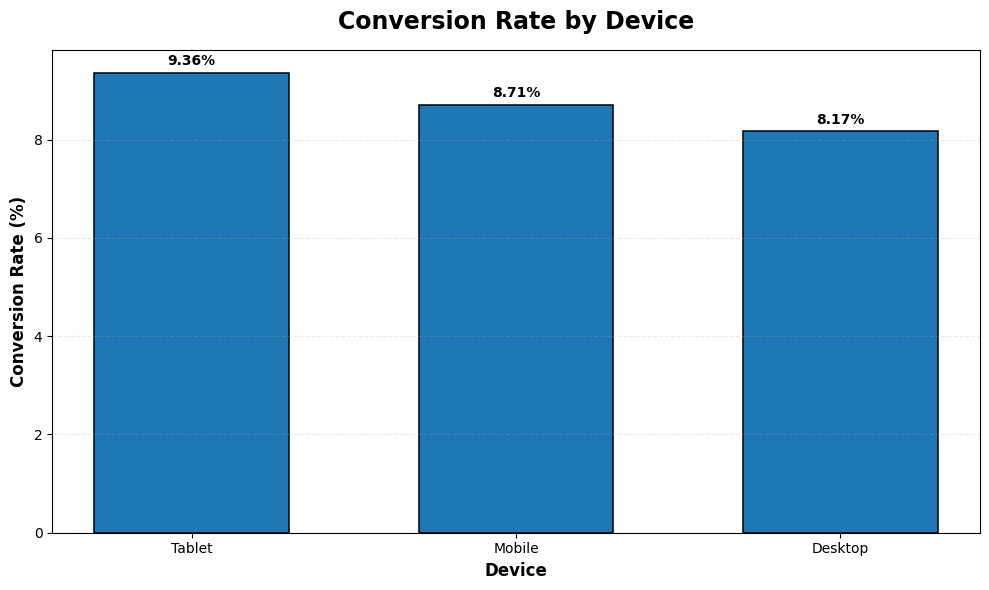

In [36]:
device_sorted = device_summary.sort_values(
    'Conversion_Rate',
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    device_sorted['Device'],
    device_sorted['Conversion_Rate'],
    edgecolor='black',
    linewidth=1.1,
    width=0.6
)

plt.title(
    'Conversion Rate by Device',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Device',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Conversion Rate (%)',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.15,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()

plt.savefig(
    '10_device_conversion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

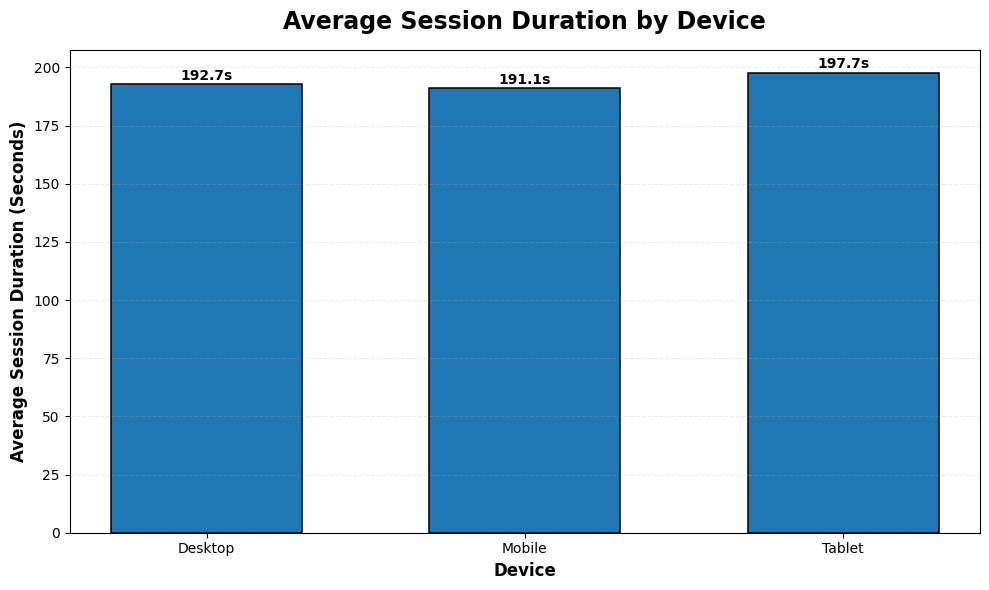

In [37]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    device_summary['Device'],
    device_summary['Avg_Session_Duration'],
    edgecolor='black',
    linewidth=1.1,
    width=0.6
)

plt.title(
    'Average Session Duration by Device',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Device',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Average Session Duration (Seconds)',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        f'{value:.1f}s',
        ha='center',
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()

plt.savefig(
    '11_device_session_duration.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [38]:
conversion_engagement = master_df.groupby(
    'Purchase'
).agg(
    Sessions=('Customer_ID', 'count'),
    Avg_Session_Duration=(
        'Session_Duration_Seconds',
        'mean'
    ),
    Avg_Pages_Viewed=('Pages_Viewed', 'mean'),
    Bounce_Rate=('Bounce', 'mean')
).reset_index()

conversion_engagement['Bounce_Rate'] *= 100

conversion_engagement['Status'] = (
    conversion_engagement['Purchase']
    .map({
        0: 'Non-Converted',
        1: 'Converted'
    })
)

conversion_engagement = conversion_engagement.round(2)

display(conversion_engagement)

,Purchase,Sessions,Avg_Session_Duration,Avg_Pages_Viewed,Bounce_Rate,Status
0,0,5485,190.83,2.88,36.13,Non-Converted
1,1,515,204.65,3.16,33.01,Converted


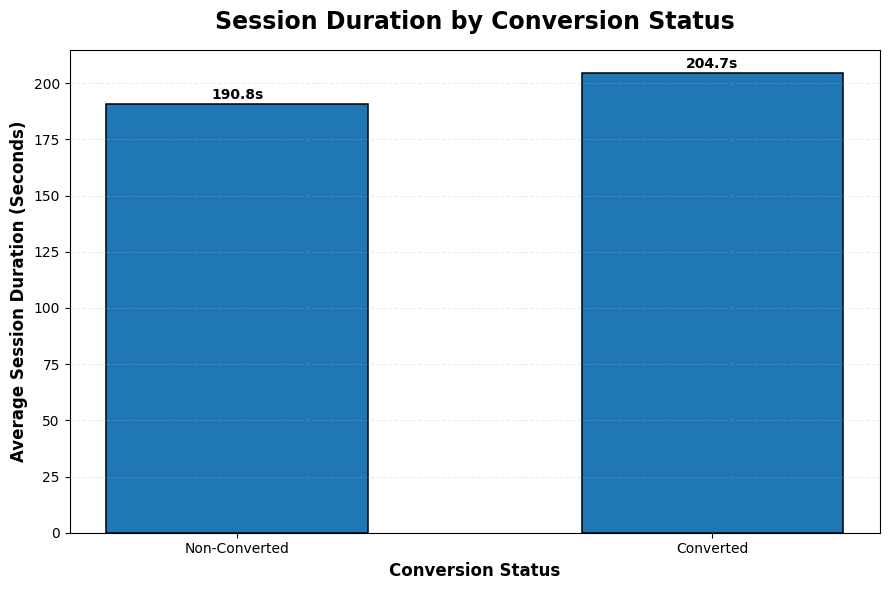

In [39]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    conversion_engagement['Status'],
    conversion_engagement['Avg_Session_Duration'],
    edgecolor='black',
    linewidth=1.1,
    width=0.55
)

plt.title(
    'Session Duration by Conversion Status',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Conversion Status',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Average Session Duration (Seconds)',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        f'{value:.1f}s',
        ha='center',
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    '12_engagement_by_conversion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [40]:
highest_traffic_conversion = traffic_summary.loc[
    traffic_summary['Conversion_Rate'].idxmax()
]

highest_traffic_bounce = traffic_summary.loc[
    traffic_summary['Bounce_Rate'].idxmax()
]

highest_device_conversion = device_summary.loc[
    device_summary['Conversion_Rate'].idxmax()
]

lowest_device_conversion = device_summary.loc[
    device_summary['Conversion_Rate'].idxmin()
]

print("===== WEBSITE ANALYTICS INSIGHTS =====\n")

print(
    f"Best Traffic Source by Conversion: "
    f"{highest_traffic_conversion['Traffic_Source']} "
    f"({highest_traffic_conversion['Conversion_Rate']:.2f}%)"
)

print(
    f"Highest Bounce Traffic Source: "
    f"{highest_traffic_bounce['Traffic_Source']} "
    f"({highest_traffic_bounce['Bounce_Rate']:.2f}%)"
)

print(
    f"Best Converting Device: "
    f"{highest_device_conversion['Device']} "
    f"({highest_device_conversion['Conversion_Rate']:.2f}%)"
)

print(
    f"Lowest Converting Device: "
    f"{lowest_device_conversion['Device']} "
    f"({lowest_device_conversion['Conversion_Rate']:.2f}%)"
)

===== WEBSITE ANALYTICS INSIGHTS =====

Best Traffic Source by Conversion: Paid Ads (9.72%)
Highest Bounce Traffic Source: Direct (37.43%)
Best Converting Device: Tablet (9.36%)
Lowest Converting Device: Desktop (8.17%)


In [41]:
funnel_summary.to_csv(
    'final_conversion_funnel.csv',
    index=False
)

conversion_engagement.to_csv(
    'final_conversion_engagement_summary.csv',
    index=False
)

print(
    "✅ Website analytics analysis saved successfully!"
)

✅ Website analytics analysis saved successfully!


## Pricing Strategy Evaluation

The pricing analysis compares three eCommerce pricing strategies:

- Control Pricing
- Discount Pricing
- Premium Pricing

The purpose is to determine whether pricing changes influence
conversion, revenue, and estimated profitability.

The analysis combines business KPIs with statistical testing so that
the final recommendation is not based only on conversion rate.

In [42]:
pricing_final_analysis = master_df.groupby(
    'Pricing_Group'
).agg(
    Visitors=('Customer_ID', 'count'),
    Purchases=('Purchase', 'sum'),
    Conversion_Rate=('Purchase', 'mean'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Estimated_Profit', 'sum')
).reset_index()

pricing_final_analysis['Conversion_Rate'] *= 100

pricing_final_analysis['Revenue_Per_Visitor'] = (
    pricing_final_analysis['Total_Revenue']
    / pricing_final_analysis['Visitors']
)

pricing_final_analysis['Profit_Per_Visitor'] = (
    pricing_final_analysis['Total_Profit']
    / pricing_final_analysis['Visitors']
)

pricing_final_analysis = pricing_final_analysis.round(2)

display(pricing_final_analysis)

,Pricing_Group,Visitors,Purchases,Conversion_Rate,Total_Revenue,Total_Profit,Revenue_Per_Visitor,Profit_Per_Visitor
0,Control,1954,172,8.80,220000,88000,112.59,45.04
1,Discount,1954,192,9.83,233100,77700,119.29,39.76
2,Premium,2092,151,7.22,237600,108000,113.58,51.63


In [43]:
from scipy.stats import chi2_contingency

pricing_contingency = pd.crosstab(
    master_df['Pricing_Group'],
    master_df['Purchase']
)

display(pricing_contingency)

chi2, pricing_p_value, dof, expected = chi2_contingency(
    pricing_contingency
)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {pricing_p_value:.6f}")

if pricing_p_value < 0.05:
    print("✅ Significant association detected.")
else:
    print("⚠️ No statistically significant association detected.")

Purchase,0,1
Pricing_Group,,
Control,1782,172
Discount,1762,192
Premium,1941,151


Chi-Square Statistic: 8.9353
P-value: 0.011474
✅ Significant association detected.


In [44]:
from statsmodels.stats.proportion import proportion_confint

pricing_ci_results = []

for _, row in pricing_final_analysis.iterrows():

    group = row['Pricing_Group']

    purchases = int(
        master_df[
            master_df['Pricing_Group'] == group
        ]['Purchase'].sum()
    )

    visitors = int(
        (
            master_df['Pricing_Group'] == group
        ).sum()
    )

    rate = purchases / visitors

    lower, upper = proportion_confint(
        count=purchases,
        nobs=visitors,
        alpha=0.05,
        method='wilson'
    )

    pricing_ci_results.append({
        'Pricing_Group': group,
        'Conversion_Rate_%': rate * 100,
        'CI_Lower_%': lower * 100,
        'CI_Upper_%': upper * 100
    })

pricing_ci_df = pd.DataFrame(
    pricing_ci_results
).round(2)

display(pricing_ci_df)

,Pricing_Group,Conversion_Rate_%,CI_Lower_%,CI_Upper_%
0,Control,8.80,7.63,10.14
1,Discount,9.83,8.58,11.23
2,Premium,7.22,6.19,8.41


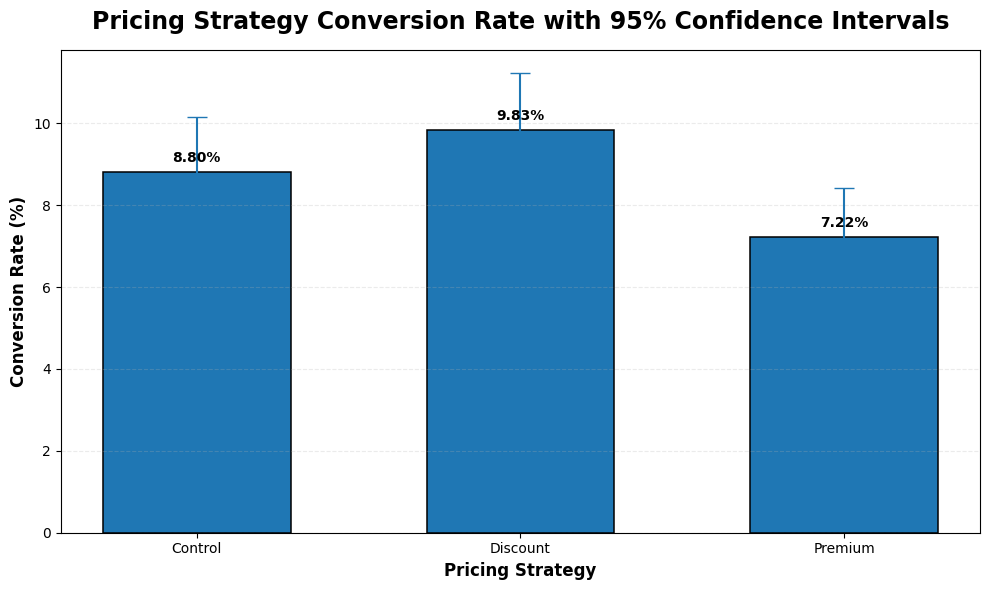

In [45]:
rates = pricing_ci_df['Conversion_Rate_%']

lower_error = (
    rates - pricing_ci_df['CI_Lower_%']
)

upper_error = (
    pricing_ci_df['CI_Upper_%'] - rates
)

errors = np.array([
    lower_error,
    upper_error
])

plt.figure(figsize=(10, 6))

bars = plt.bar(
    pricing_ci_df['Pricing_Group'],
    rates,
    width=0.58,
    edgecolor='black',
    linewidth=1.1
)

plt.errorbar(
    pricing_ci_df['Pricing_Group'],
    rates,
    yerr=errors,
    fmt='none',
    capsize=7,
    linewidth=1.5
)

plt.title(
    'Pricing Strategy Conversion Rate with 95% Confidence Intervals',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Pricing Strategy',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Conversion Rate (%)',
    fontsize=12,
    fontweight='bold'
)

for bar, value in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.25,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    '13_pricing_conversion_ci.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

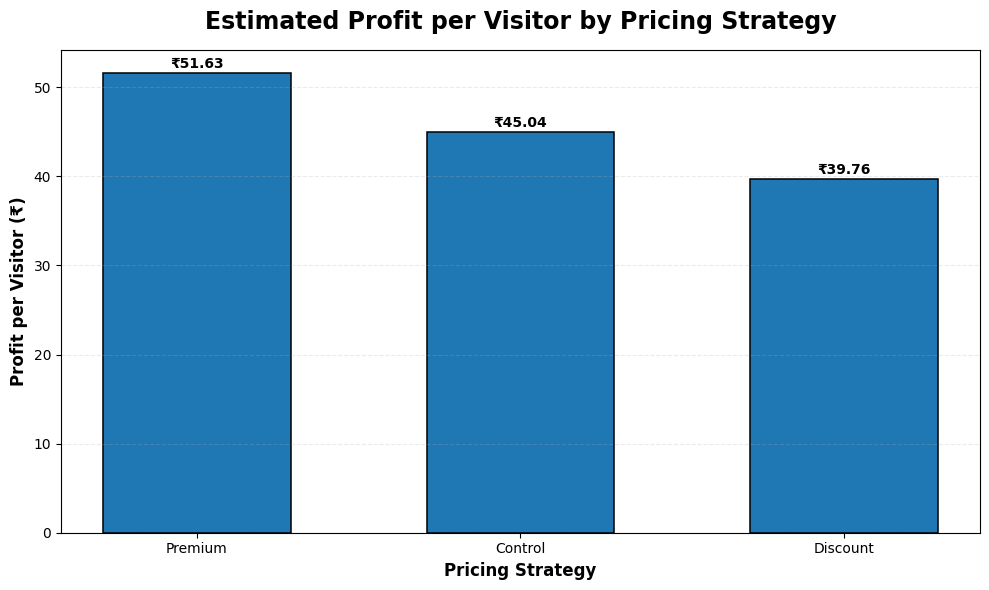

In [46]:
pricing_profit_sorted = pricing_final_analysis.sort_values(
    'Profit_Per_Visitor',
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    pricing_profit_sorted['Pricing_Group'],
    pricing_profit_sorted['Profit_Per_Visitor'],
    width=0.58,
    edgecolor='black',
    linewidth=1.1
)

plt.title(
    'Estimated Profit per Visitor by Pricing Strategy',
    fontsize=17,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Pricing Strategy',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Profit per Visitor (₹)',
    fontsize=12,
    fontweight='bold'
)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.5,
        f'₹{value:.2f}',
        ha='center',
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    '14_pricing_profit_per_visitor.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [47]:
best_pricing_conversion = pricing_final_analysis.loc[
    pricing_final_analysis[
        'Conversion_Rate'
    ].idxmax()
]

best_pricing_profit = pricing_final_analysis.loc[
    pricing_final_analysis[
        'Profit_Per_Visitor'
    ].idxmax()
]

print("===== PRICING ANALYSIS INSIGHTS =====\n")

print(
    f"Highest Conversion Strategy: "
    f"{best_pricing_conversion['Pricing_Group']} "
    f"({best_pricing_conversion['Conversion_Rate']:.2f}%)"
)

print(
    f"Highest Profit per Visitor: "
    f"{best_pricing_profit['Pricing_Group']} "
    f"(₹{best_pricing_profit['Profit_Per_Visitor']:.2f})"
)

print(
    f"Overall Statistical P-value: "
    f"{pricing_p_value:.6f}"
)

===== PRICING ANALYSIS INSIGHTS =====

Highest Conversion Strategy: Discount (9.83%)
Highest Profit per Visitor: Premium (₹51.63)
Overall Statistical P-value: 0.011474


In [48]:
pricing_final_analysis.to_csv(
    'final_integrated_pricing_analysis.csv',
    index=False
)

pricing_ci_df.to_csv(
    'final_pricing_confidence_intervals.csv',
    index=False
)

pricing_test_summary = pd.DataFrame({
    'Test': ['Chi-Square Test'],
    'Statistic': [chi2],
    'P_Value': [pricing_p_value],
    'Degrees_of_Freedom': [dof],
    'Significant_At_0.05': [
        pricing_p_value < 0.05
    ]
})

pricing_test_summary.to_csv(
    'final_pricing_statistical_test.csv',
    index=False
)

print(
    "✅ Pricing analysis saved successfully!"
)

✅ Pricing analysis saved successfully!


## Cross-Analysis and Integrated Business Insights

This section connects customer behavior, website engagement, traffic
sources, device usage, pricing strategies, and financial outcomes.

The objective is to identify relationships that may not be visible
when each analytical area is examined independently.

Cross-analysis helps transform individual analytical findings into
actionable eCommerce business insights.

In [49]:
segment_pricing = master_df.groupby(
    ['Customer_Segment', 'Pricing_Group']
).agg(
    Customers=('Customer_ID', 'count'),
    Purchases=('Purchase', 'sum'),
    Conversion_Rate=('Purchase', 'mean'),
    Revenue=('Revenue', 'sum'),
    Profit=('Estimated_Profit', 'sum')
).reset_index()

segment_pricing['Conversion_Rate'] *= 100

segment_pricing['Revenue_Per_Customer'] = (
    segment_pricing['Revenue']
    / segment_pricing['Customers']
)

segment_pricing['Profit_Per_Customer'] = (
    segment_pricing['Profit']
    / segment_pricing['Customers']
)

segment_pricing = segment_pricing.round(2)

display(segment_pricing)

,Customer_Segment,Pricing_Group,Customers,Purchases,Conversion_Rate,Revenue,Profit,Revenue_Per_Customer,Profit_Per_Customer
0,At Risk,Control,307,10,3.26,13000,5200,42.35,16.94
1,At Risk,Discount,285,17,5.96,19800,6600,69.47,23.16
2,At Risk,Premium,315,14,4.44,25300,11500,80.32,36.51
3,High Value,Control,365,34,9.32,38000,15200,104.11,41.64
4,High Value,Discount,339,36,10.62,45000,15000,132.74,44.25
5,High Value,Premium,352,30,8.52,44000,20000,125.00,56.82
6,Occasional,Control,506,42,8.30,51000,20400,100.79,40.32
7,Occasional,Discount,492,48,9.76,63000,21000,128.05,42.68
8,Occasional,Premium,491,32,6.52,51700,23500,105.30,47.86
9,Regular,Control,776,86,11.08,118000,47200,152.06,60.82


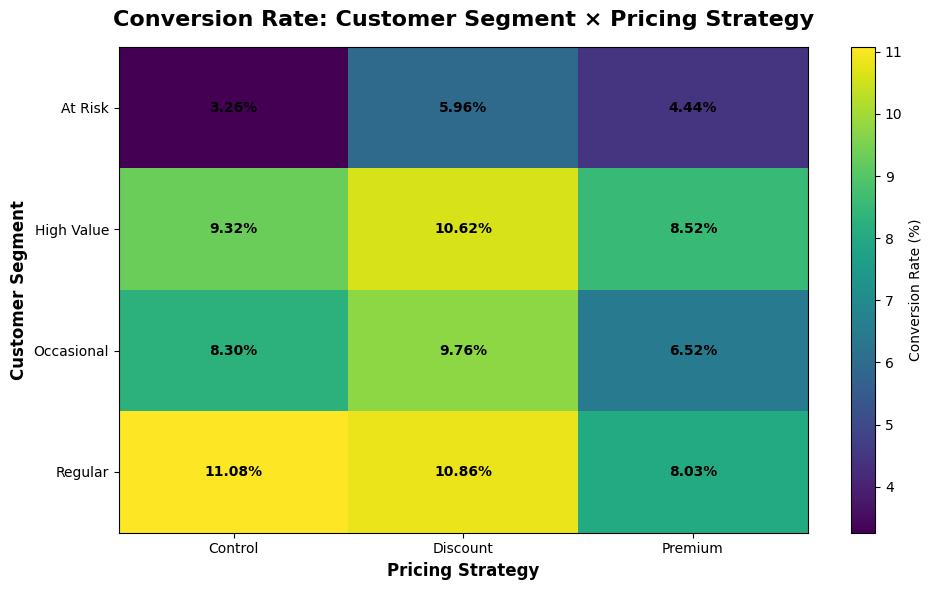

In [50]:
segment_pricing_pivot = segment_pricing.pivot(
    index='Customer_Segment',
    columns='Pricing_Group',
    values='Conversion_Rate'
)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    segment_pricing_pivot.values,
    aspect='auto'
)

ax.set_xticks(
    range(len(segment_pricing_pivot.columns))
)

ax.set_xticklabels(
    segment_pricing_pivot.columns
)

ax.set_yticks(
    range(len(segment_pricing_pivot.index))
)

ax.set_yticklabels(
    segment_pricing_pivot.index
)

for i in range(len(segment_pricing_pivot.index)):
    for j in range(len(segment_pricing_pivot.columns)):

        value = segment_pricing_pivot.iloc[i, j]

        ax.text(
            j,
            i,
            f'{value:.2f}%',
            ha='center',
            va='center',
            fontweight='bold'
        )

plt.title(
    'Conversion Rate: Customer Segment × Pricing Strategy',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Pricing Strategy',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Customer Segment',
    fontsize=12,
    fontweight='bold'
)

plt.colorbar(
    im,
    label='Conversion Rate (%)'
)

plt.tight_layout()

plt.savefig(
    '15_segment_pricing_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [51]:
traffic_device = master_df.groupby(
    ['Traffic_Source', 'Device']
).agg(
    Sessions=('Customer_ID', 'count'),
    Conversion_Rate=('Purchase', 'mean'),
    Bounce_Rate=('Bounce', 'mean'),
    Revenue=('Revenue', 'sum')
).reset_index()

traffic_device['Conversion_Rate'] *= 100
traffic_device['Bounce_Rate'] *= 100

traffic_device['Revenue_Per_Session'] = (
    traffic_device['Revenue']
    / traffic_device['Sessions']
)

traffic_device = traffic_device.round(2)

display(traffic_device)

,Traffic_Source,Device,Sessions,Conversion_Rate,Bounce_Rate,Revenue,Revenue_Per_Session
0,Direct,Desktop,349,8.88,36.39,41300,118.34
1,Direct,Mobile,630,7.62,38.10,61500,97.62
2,Direct,Tablet,87,11.49,36.78,12600,144.83
3,Email,Desktop,223,5.83,31.39,16700,74.89
4,Email,Mobile,430,9.53,38.37,53900,125.35
5,Email,Tablet,43,11.63,18.60,7400,172.09
6,Organic Search,Desktop,592,7.09,36.49,56600,95.61
7,Organic Search,Mobile,1110,8.20,34.32,132000,118.92
8,Organic Search,Tablet,130,9.23,37.69,15200,116.92
9,Paid Ads,Desktop,397,9.32,42.32,47600,119.90


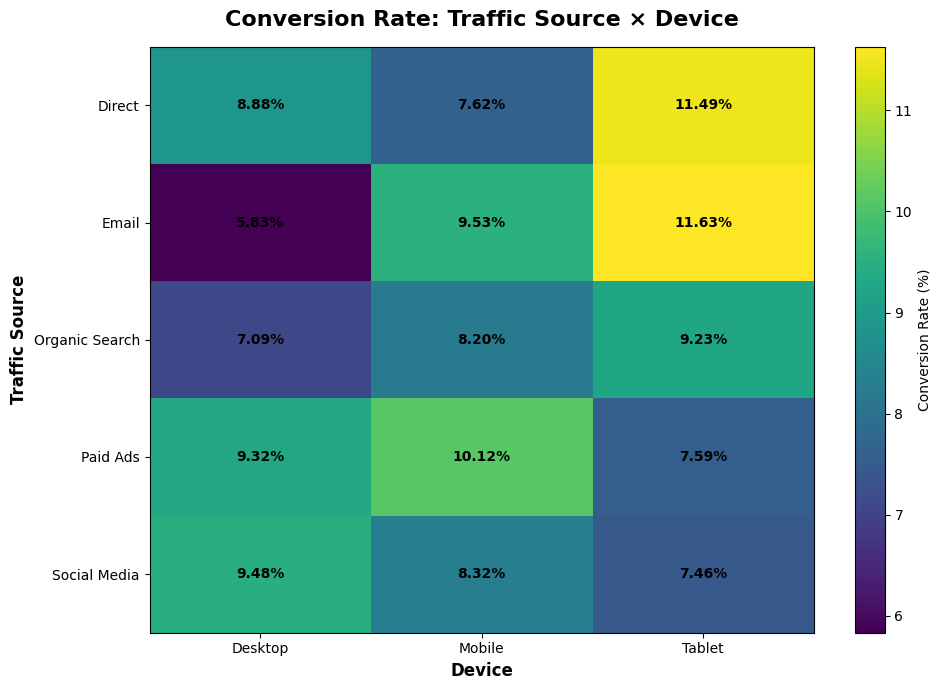

In [52]:
traffic_device_pivot = traffic_device.pivot(
    index='Traffic_Source',
    columns='Device',
    values='Conversion_Rate'
)

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    traffic_device_pivot.values,
    aspect='auto'
)

ax.set_xticks(
    range(len(traffic_device_pivot.columns))
)

ax.set_xticklabels(
    traffic_device_pivot.columns
)

ax.set_yticks(
    range(len(traffic_device_pivot.index))
)

ax.set_yticklabels(
    traffic_device_pivot.index
)

for i in range(len(traffic_device_pivot.index)):
    for j in range(len(traffic_device_pivot.columns)):

        value = traffic_device_pivot.iloc[i, j]

        ax.text(
            j,
            i,
            f'{value:.2f}%',
            ha='center',
            va='center',
            fontweight='bold'
        )

plt.title(
    'Conversion Rate: Traffic Source × Device',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Device',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Traffic Source',
    fontsize=12,
    fontweight='bold'
)

plt.colorbar(
    im,
    label='Conversion Rate (%)'
)

plt.tight_layout()

plt.savefig(
    '16_traffic_device_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [53]:
correlation_columns = [
    'Session_Duration_Seconds',
    'Pages_Viewed',
    'Bounce',
    'Price_Shown',
    'Purchase',
    'Quantity',
    'Revenue',
    'Estimated_Profit'
]

correlation_matrix = master_df[
    correlation_columns
].corr()

display(
    correlation_matrix.round(2)
)

,Session_Duration_Seconds,Pages_Viewed,Bounce,Price_Shown,Purchase,Quantity,Revenue,Estimated_Profit
Session_Duration_Seconds,1.00,0.69,-0.25,-0.00,0.03,0.03,0.03,0.03
Pages_Viewed,0.69,1.00,-0.25,0.00,0.04,0.04,0.04,0.04
Bounce,-0.25,-0.25,1.00,-0.01,-0.02,-0.01,-0.02,-0.02
Price_Shown,-0.00,0.00,-0.01,1.00,-0.04,-0.03,-0.01,0.03
Purchase,0.03,0.04,-0.02,-0.04,1.00,0.91,0.91,0.88
Quantity,0.03,0.04,-0.01,-0.03,0.91,1.00,1.00,0.98
Revenue,0.03,0.04,-0.02,-0.01,0.91,1.00,1.00,0.99
Estimated_Profit,0.03,0.04,-0.02,0.03,0.88,0.98,0.99,1.00


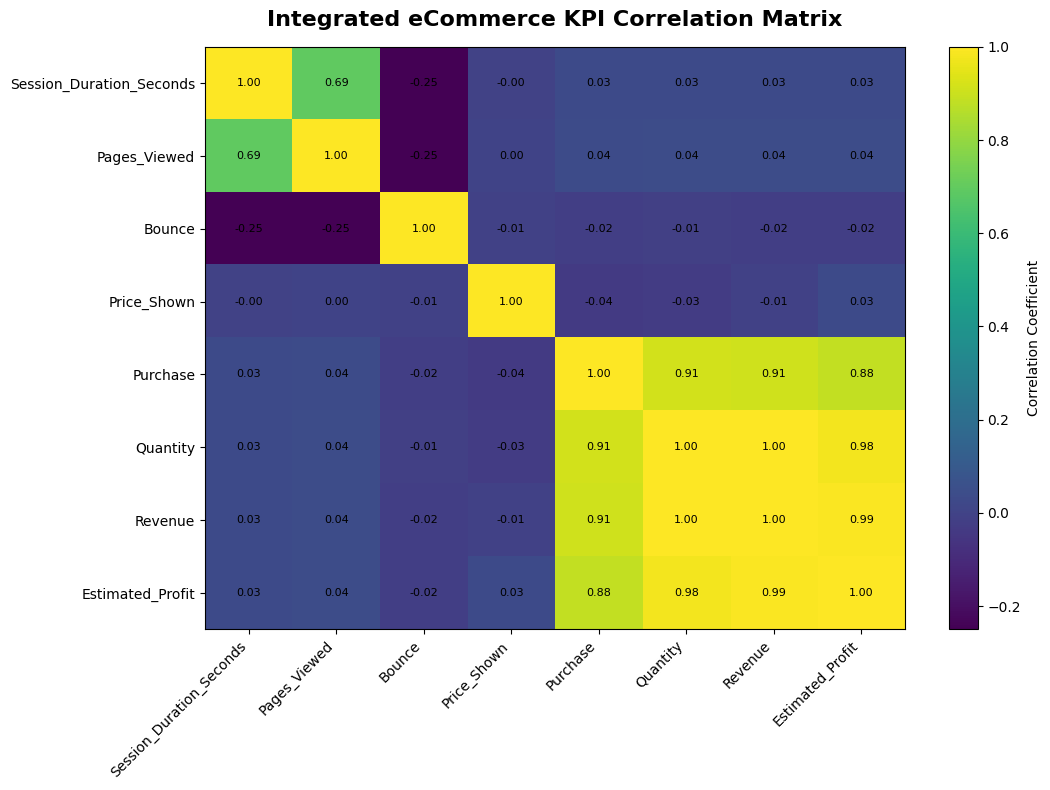

In [54]:
fig, ax = plt.subplots(figsize=(11, 8))

im = ax.imshow(
    correlation_matrix.values,
    aspect='auto'
)

ax.set_xticks(
    range(len(correlation_columns))
)

ax.set_xticklabels(
    correlation_columns,
    rotation=45,
    ha='right'
)

ax.set_yticks(
    range(len(correlation_columns))
)

ax.set_yticklabels(
    correlation_columns
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):

        value = correlation_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f'{value:.2f}',
            ha='center',
            va='center',
            fontsize=8
        )

plt.title(
    'Integrated eCommerce KPI Correlation Matrix',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.colorbar(
    im,
    label='Correlation Coefficient'
)

plt.tight_layout()

plt.savefig(
    '17_integrated_correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [55]:
purchase_correlations = (
    correlation_matrix['Purchase']
    .drop('Purchase')
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(
    "===== VARIABLES MOST ASSOCIATED "
    "WITH PURCHASE =====\n"
)

print(
    purchase_correlations.round(3)
)

===== VARIABLES MOST ASSOCIATED WITH PURCHASE =====

Quantity                    0.914
Revenue                     0.907
Estimated_Profit            0.885
Price_Shown                -0.038
Pages_Viewed                0.037
Session_Duration_Seconds    0.031
Bounce                     -0.018
Name: Purchase, dtype: float64


In [56]:
pre_purchase_variables = [
    'Session_Duration_Seconds',
    'Pages_Viewed',
    'Bounce',
    'Price_Shown',
    'Purchase'
]

pre_purchase_corr = master_df[
    pre_purchase_variables
].corr()

purchase_driver_corr = (
    pre_purchase_corr['Purchase']
    .drop('Purchase')
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(
    "===== PRE-PURCHASE ASSOCIATIONS =====\n"
)

print(
    purchase_driver_corr.round(3)
)

===== PRE-PURCHASE ASSOCIATIONS =====

Price_Shown                -0.038
Pages_Viewed                0.037
Session_Duration_Seconds    0.031
Bounce                     -0.018
Name: Purchase, dtype: float64


In [57]:
best_segment_pricing = segment_pricing.loc[
    segment_pricing[
        'Profit_Per_Customer'
    ].idxmax()
]

best_traffic_device = traffic_device.loc[
    traffic_device[
        'Conversion_Rate'
    ].idxmax()
]

print("===== CROSS-ANALYSIS HIGHLIGHTS =====\n")

print(
    "Best Segment + Pricing Combination:",
    best_segment_pricing['Customer_Segment'],
    "+",
    best_segment_pricing['Pricing_Group']
)

print(
    f"Profit per Customer: "
    f"₹{best_segment_pricing['Profit_Per_Customer']:.2f}"
)

print()

print(
    "Best Traffic + Device Combination:",
    best_traffic_device['Traffic_Source'],
    "+",
    best_traffic_device['Device']
)

print(
    f"Conversion Rate: "
    f"{best_traffic_device['Conversion_Rate']:.2f}%"
)

===== CROSS-ANALYSIS HIGHLIGHTS =====

Best Segment + Pricing Combination: Regular + Control
Profit per Customer: ₹60.82

Best Traffic + Device Combination: Email + Tablet
Conversion Rate: 11.63%


In [58]:
segment_pricing.to_csv(
    'final_segment_pricing_analysis.csv',
    index=False
)

traffic_device.to_csv(
    'final_traffic_device_analysis.csv',
    index=False
)

correlation_matrix.to_csv(
    'final_correlation_matrix.csv'
)

pre_purchase_corr.to_csv(
    'final_pre_purchase_correlation.csv'
)

print(
    "✅ Cross-analysis results saved successfully!"
)

✅ Cross-analysis results saved successfully!


In [59]:
integrated_findings = pd.DataFrame({
    'Area': [
        'Customer Segmentation',
        'Traffic Source',
        'Device Performance',
        'Sales Forecasting',
        'Pricing Strategy',
        'Segment + Pricing Combination',
        'Traffic + Device Combination'
    ],

    'Key_Finding': [
        (
            f"{highest_revenue_segment['Customer_Segment']} generated the "
            f"highest revenue per customer at "
            f"₹{highest_revenue_segment['Revenue_Per_Customer']:.2f}."
        ),

        (
            f"{highest_traffic_conversion['Traffic_Source']} achieved the "
            f"highest traffic-source conversion rate at "
            f"{highest_traffic_conversion['Conversion_Rate']:.2f}%."
        ),

        (
            f"{highest_device_conversion['Device']} recorded the highest "
            f"device conversion rate at "
            f"{highest_device_conversion['Conversion_Rate']:.2f}%."
        ),

        (
            f"{best_forecast_method['Method']} produced the lowest "
            f"MAE of ₹{best_forecast_method['MAE']:,.2f} in the "
            f"simulated forecasting comparison."
        ),

        (
            f"{best_pricing_profit['Pricing_Group']} generated the highest "
            f"estimated profit per visitor at "
            f"₹{best_pricing_profit['Profit_Per_Visitor']:.2f}."
        ),

        (
            f"{best_segment_pricing['Customer_Segment']} + "
            f"{best_segment_pricing['Pricing_Group']} produced the "
            f"highest estimated profit per customer in the cross-analysis."
        ),

        (
            f"{best_traffic_device['Traffic_Source']} + "
            f"{best_traffic_device['Device']} achieved the highest "
            f"observed traffic-device conversion rate of "
            f"{best_traffic_device['Conversion_Rate']:.2f}%."
        )
    ]
})

display(integrated_findings)

,Area,Key_Finding
0,Customer Segmentation,Regular generated the highest revenue per cust...
1,Traffic Source,Paid Ads achieved the highest traffic-source c...
2,Device Performance,Tablet recorded the highest device conversion ...
3,Sales Forecasting,Exponential Smoothing produced the lowest MAE ...
4,Pricing Strategy,Premium generated the highest estimated profit...
5,Segment + Pricing Combination,Regular + Control produced the highest estimat...
6,Traffic + Device Combination,Email + Tablet achieved the highest observed t...


In [60]:
strategic_recommendations = pd.DataFrame({
    'Business_Area': [
        'Customer Strategy',
        'Marketing Acquisition',
        'Website CRO',
        'Device Optimization',
        'Sales Planning',
        'Pricing Strategy',
        'Customer Retention',
        'Experimentation'
    ],

    'Recommendation': [
        (
            'Prioritize high-value customer segments with personalized '
            'offers, loyalty programs, and targeted retention campaigns.'
        ),

        (
            'Allocate acquisition budgets using both traffic volume and '
            'conversion quality rather than relying on sessions alone.'
        ),

        (
            'Reduce friction across the website journey by improving '
            'landing-page relevance, navigation, product discovery, '
            'and checkout usability.'
        ),

        (
            'Investigate lower-performing device experiences and optimize '
            'responsive layout, speed, forms, CTA visibility, and checkout.'
        ),

        (
            'Use forecast trends to support inventory, staffing, campaign, '
            'and revenue-planning decisions while monitoring forecast error.'
        ),

        (
            'Evaluate pricing using conversion, revenue per visitor, '
            'profit per visitor, and statistical evidence together.'
        ),

        (
            'Develop retention strategies for occasional and at-risk '
            'customers using re-engagement campaigns and relevant offers.'
        ),

        (
            'Validate major website and pricing changes through controlled '
            'A/B testing before broad deployment.'
        )
    ],

    'Expected_Business_Impact': [
        'Higher customer lifetime value',
        'Improved marketing efficiency',
        'Higher funnel progression',
        'Improved conversion experience',
        'Better operational planning',
        'Stronger profitability decisions',
        'Improved retention',
        'Lower decision risk'
    ]
})

display(strategic_recommendations)

,Business_Area,Recommendation,Expected_Business_Impact
0,Customer Strategy,Prioritize high-value customer segments with p...,Higher customer lifetime value
1,Marketing Acquisition,Allocate acquisition budgets using both traffi...,Improved marketing efficiency
2,Website CRO,Reduce friction across the website journey by ...,Higher funnel progression
3,Device Optimization,Investigate lower-performing device experience...,Improved conversion experience
4,Sales Planning,"Use forecast trends to support inventory, staf...",Better operational planning
5,Pricing Strategy,"Evaluate pricing using conversion, revenue per...",Stronger profitability decisions
6,Customer Retention,Develop retention strategies for occasional an...,Improved retention
7,Experimentation,Validate major website and pricing changes thr...,Lower decision risk


In [61]:
future_directions = pd.DataFrame({
    'Future_Area': [
        'Predictive Customer Churn',
        'Customer Lifetime Value',
        'Recommendation Systems',
        'Advanced Forecasting',
        'Dynamic Pricing',
        'Real-Time Analytics',
        'Marketing Attribution',
        'Cloud-Based Analytics'
    ],

    'Potential_Application': [
        'Identify customers likely to stop purchasing.',
        'Estimate long-term value of different customer groups.',
        'Provide personalized product recommendations.',
        'Apply ARIMA, Prophet, or machine-learning forecasting models.',
        'Adjust prices using demand, inventory, and customer behavior.',
        'Track KPIs and anomalies using streaming dashboards.',
        'Measure contribution of multiple marketing touchpoints.',
        'Deploy scalable analytics pipelines and dashboards in the cloud.'
    ]
})

display(future_directions)

,Future_Area,Potential_Application
0,Predictive Customer Churn,Identify customers likely to stop purchasing.
1,Customer Lifetime Value,Estimate long-term value of different customer...
2,Recommendation Systems,Provide personalized product recommendations.
3,Advanced Forecasting,"Apply ARIMA, Prophet, or machine-learning fore..."
4,Dynamic Pricing,"Adjust prices using demand, inventory, and cus..."
5,Real-Time Analytics,Track KPIs and anomalies using streaming dashb...
6,Marketing Attribution,Measure contribution of multiple marketing tou...
7,Cloud-Based Analytics,Deploy scalable analytics pipelines and dashbo...


## Integrated Interpretation

The final analysis demonstrates that eCommerce performance should not
be evaluated using a single metric or analytical technique.

Customer segmentation provides insight into differences in customer
value and behavior. Website analytics explains how visitors interact
with digital channels and devices. Sales forecasting supports forward
planning, while pricing experimentation evaluates the relationship
between customer response and financial performance.

Cross-analysis provides additional context by examining combinations
such as customer segment and pricing strategy or traffic source and
device.

Because the project contains simulated components, the findings should
be treated as analytical demonstrations and business hypotheses rather
than causal conclusions.

In a real implementation, the recommended strategies should be
validated using production data, controlled experiments, and continuous
performance monitoring.

In [62]:
executive_insights = pd.DataFrame({
    'Executive_Metric': [
        'Overall Conversion Rate',
        'Overall Bounce Rate',
        'Total Revenue',
        'Total Estimated Profit',
        'Best Customer Segment',
        'Best Traffic Source',
        'Best Device',
        'Best Forecasting Method',
        'Best Pricing Strategy by Profit'
    ],

    'Result': [
        f'{overall_conversion_rate:.2f}%',
        f'{overall_bounce_rate:.2f}%',
        f'₹{total_revenue:,.2f}',
        f'₹{total_profit:,.2f}',
        highest_revenue_segment['Customer_Segment'],
        highest_traffic_conversion['Traffic_Source'],
        highest_device_conversion['Device'],
        best_forecast_method['Method'],
        best_pricing_profit['Pricing_Group']
    ]
})

display(executive_insights)

,Executive_Metric,Result
0,Overall Conversion Rate,8.58%
1,Overall Bounce Rate,35.87%
2,Total Revenue,"₹690,700.00"
3,Total Estimated Profit,"₹273,700.00"
4,Best Customer Segment,Regular
5,Best Traffic Source,Paid Ads
6,Best Device,Tablet
7,Best Forecasting Method,Exponential Smoothing
8,Best Pricing Strategy by Profit,Premium


In [63]:
recommendation_priority = pd.DataFrame({
    'Priority': [
        'High',
        'High',
        'High',
        'Medium',
        'Medium',
        'Medium'
    ],

    'Action': [
        'Optimize high-drop-off and low-converting website experiences',
        'Protect and grow high-value customer segments',
        'Validate the preferred pricing strategy through controlled testing',
        'Improve lower-performing acquisition channels',
        'Use forecasting results for inventory and campaign planning',
        'Develop retention strategies for at-risk customers'
    ],

    'Primary_Metric': [
        'Conversion Rate',
        'Revenue per Customer',
        'Profit per Visitor',
        'Traffic Conversion Rate',
        'Forecast Error / Revenue',
        'Retention / Repeat Purchase'
    ]
})

display(recommendation_priority)

,Priority,Action,Primary_Metric
0,High,Optimize high-drop-off and low-converting webs...,Conversion Rate
1,High,Protect and grow high-value customer segments,Revenue per Customer
2,High,Validate the preferred pricing strategy throug...,Profit per Visitor
3,Medium,Improve lower-performing acquisition channels,Traffic Conversion Rate
4,Medium,Use forecasting results for inventory and camp...,Forecast Error / Revenue
5,Medium,Develop retention strategies for at-risk custo...,Retention / Repeat Purchase


In [64]:
integrated_findings.to_csv(
    'final_integrated_findings.csv',
    index=False
)

strategic_recommendations.to_csv(
    'final_strategic_recommendations.csv',
    index=False
)

future_directions.to_csv(
    'final_future_directions.csv',
    index=False
)

executive_insights.to_csv(
    'final_executive_insights.csv',
    index=False
)

recommendation_priority.to_csv(
    'final_recommendation_priority.csv',
    index=False
)

print("✅ Integrated findings and recommendations saved successfully!")

✅ Integrated findings and recommendations saved successfully!


In [65]:
!pip install python-docx -q

print("✅ python-docx ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.7 MB/s eta 0:00:00
✅ python-docx ready!


In [66]:
import os

final_charts = [
    '01_customer_segment_conversion.png',
    '02_customer_segment_revenue.png',
    '03_customer_segment_engagement.png',
    '04_monthly_sales_trend.png',
    '05_sales_forecast_comparison.png',
    '06_forecasting_model_mae.png',
    '07_integrated_conversion_funnel.png',
    '08_traffic_source_conversion.png',
    '09_traffic_source_bounce.png',
    '10_device_conversion.png',
    '11_device_session_duration.png',
    '12_engagement_by_conversion.png',
    '13_pricing_conversion_ci.png',
    '14_pricing_profit_per_visitor.png',
    '15_segment_pricing_heatmap.png',
    '16_traffic_device_heatmap.png',
    '17_integrated_correlation_heatmap.png'
]

missing_charts = []

for chart in final_charts:
    if os.path.exists(chart):
        print("✅", chart)
    else:
        print("❌", chart)
        missing_charts.append(chart)

print("\nTotal charts:", len(final_charts))
print("Missing:", len(missing_charts))

✅ 01_customer_segment_conversion.png
✅ 02_customer_segment_revenue.png
✅ 03_customer_segment_engagement.png
✅ 04_monthly_sales_trend.png
✅ 05_sales_forecast_comparison.png
✅ 06_forecasting_model_mae.png
✅ 07_integrated_conversion_funnel.png
✅ 08_traffic_source_conversion.png
✅ 09_traffic_source_bounce.png
✅ 10_device_conversion.png
✅ 11_device_session_duration.png
✅ 12_engagement_by_conversion.png
✅ 13_pricing_conversion_ci.png
✅ 14_pricing_profit_per_visitor.png
✅ 15_segment_pricing_heatmap.png
✅ 16_traffic_device_heatmap.png
✅ 17_integrated_correlation_heatmap.png

Total charts: 17
Missing: 0


In [67]:
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.enum.section import WD_SECTION
import os
import pandas as pd

# =========================================================
# CREATE DOCUMENT
# =========================================================

doc = Document()

for section in doc.sections:
    section.top_margin = Inches(0.7)
    section.bottom_margin = Inches(0.7)
    section.left_margin = Inches(0.75)
    section.right_margin = Inches(0.75)

doc.styles['Normal'].font.name = 'Arial'
doc.styles['Normal'].font.size = Pt(10.5)


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def add_title(text, size=24):
    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER

    r = p.add_run(text)
    r.bold = True
    r.font.size = Pt(size)


def add_table(df, max_rows=20):

    df = df.head(max_rows).copy()

    table = doc.add_table(
        rows=1,
        cols=len(df.columns)
    )

    table.style = 'Table Grid'
    table.alignment = WD_TABLE_ALIGNMENT.CENTER

    for i, col in enumerate(df.columns):

        cell = table.rows[0].cells[i]
        cell.text = str(col)

        for run in cell.paragraphs[0].runs:
            run.bold = True
            run.font.size = Pt(8.5)

    for _, row in df.iterrows():

        cells = table.add_row().cells

        for i, value in enumerate(row):

            cells[i].text = str(value)

            for run in cells[i].paragraphs[0].runs:
                run.font.size = Pt(8)

    doc.add_paragraph()


def add_chart(filename, title, interpretation):

    if not os.path.exists(filename):
        print("⚠️ Missing:", filename)
        return

    doc.add_heading(title, level=3)

    p = doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER

    p.add_run().add_picture(
        filename,
        width=Inches(6.2)
    )

    caption = doc.add_paragraph()
    caption.alignment = WD_ALIGN_PARAGRAPH.CENTER

    r = caption.add_run(title)
    r.bold = True
    r.italic = True
    r.font.size = Pt(9)

    p = doc.add_paragraph()

    r = p.add_run("Interpretation: ")
    r.bold = True

    p.add_run(interpretation)


# =========================================================
# COVER PAGE
# =========================================================

doc.add_paragraph("\n\n")

add_title(
    "Comprehensive Retail eCommerce\nData Analysis Report",
    25
)

doc.add_paragraph()

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

r = p.add_run(
    "Final Internship Project"
)
r.bold = True
r.font.size = Pt(16)

doc.add_paragraph("\n")

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

r = p.add_run(
    "End-to-End eCommerce Data Analytics"
)
r.font.size = Pt(14)

doc.add_paragraph("\n")

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

p.add_run(
    "Customer Analytics | Sales Forecasting | Website Analytics | "
    "Conversion Optimization | Pricing Experimentation"
).italic = True

doc.add_paragraph("\n\n")

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

p.add_run("Prepared by\n").bold = True
p.add_run("Nishant Kumar Nishee\n")
p.add_run("B.Tech – Computer Science and Engineering\n")
p.add_run("Centurion University of Technology and Management")

doc.add_page_break()


# =========================================================
# 1. EXECUTIVE SUMMARY
# =========================================================

doc.add_heading(
    '1. Executive Summary',
    level=1
)

doc.add_paragraph(
    f"""
This comprehensive project integrates multiple analytical techniques
to evaluate the performance of a simulated retail eCommerce platform.
The analysis covers data strategy, customer segmentation, sales
forecasting, website performance, conversion rate optimization,
pricing experimentation, and cross-functional business analysis.

The integrated customer-level dataset contains {len(master_df):,}
observations and combines customer segments, acquisition channels,
devices, website engagement, pricing conditions, purchase outcomes,
revenue, and estimated profitability.

The simulated platform achieved an overall conversion rate of
{overall_conversion_rate:.2f}% and a bounce rate of
{overall_bounce_rate:.2f}%. Total simulated revenue was
₹{total_revenue:,.2f}, while total estimated profit was
₹{total_profit:,.2f}.

The analysis identified
{highest_revenue_segment['Customer_Segment']} as the strongest segment
by revenue per customer,
{highest_traffic_conversion['Traffic_Source']} as the highest-converting
traffic source, and {highest_device_conversion['Device']} as the
highest-converting device category.

Sales forecasting was evaluated using moving averages, linear
regression, and exponential smoothing. In the model-fit comparison,
{best_forecast_method['Method']} produced the lowest MAE.

Pricing analysis evaluated Control, Discount, and Premium strategies.
{best_pricing_profit['Pricing_Group']} generated the highest observed
estimated profit per visitor in the integrated simulation.

The findings demonstrate that eCommerce performance should be evaluated
through an integrated framework rather than through isolated KPIs.
Customer value, engagement, acquisition quality, pricing, conversion,
revenue, and profitability should be considered together when making
business decisions.
"""
)


# =========================================================
# 2. INTRODUCTION
# =========================================================

doc.add_heading(
    '2. Introduction',
    level=1
)

doc.add_paragraph(
    """
Modern eCommerce platforms generate large volumes of data across
customer interactions, transactions, digital marketing channels,
devices, pricing experiments, and website behavior.

Analyzing these areas independently can provide useful information,
but stronger business decisions require an integrated analytical
approach.

This project combines the analytical methods developed throughout the
internship into a single end-to-end retail eCommerce analysis. The
project demonstrates how data can move from collection and preparation
to descriptive analysis, forecasting, experimentation, integrated
insights, and strategic recommendations.

The analysis uses simulated data for educational purposes. Therefore,
the findings demonstrate analytical methodology and business reasoning
rather than actual performance of a specific retailer.
"""
)


# =========================================================
# 3. PROJECT OBJECTIVES
# =========================================================

doc.add_heading(
    '3. Project Objectives',
    level=1
)

objectives = [
    "Develop an integrated eCommerce analytics framework.",
    "Evaluate customer segments and behavioral differences.",
    "Analyze revenue trends and forecast future sales performance.",
    "Measure website engagement and conversion performance.",
    "Compare acquisition channels and device categories.",
    "Evaluate alternative pricing strategies using statistical testing.",
    "Identify relationships across multiple analytical dimensions.",
    "Translate analytical findings into actionable business recommendations.",
    "Identify future opportunities for advanced eCommerce analytics."
]

for item in objectives:
    doc.add_paragraph(
        item,
        style='List Bullet'
    )


# =========================================================
# 4. DATA STRATEGY
# =========================================================

doc.add_heading(
    '4. eCommerce Data Strategy',
    level=1
)

doc.add_paragraph(
    """
The data strategy is designed around the complete customer and business
journey. Data sources can include website analytics, transaction
records, customer profiles, marketing channels, pricing experiments,
product interactions, and operational systems.

The analytical process follows five major stages: data collection,
preparation, analysis, interpretation, and business action.

Core business KPIs include conversion rate, bounce rate, session
duration, revenue per customer, profit per customer, customer-segment
performance, traffic-source performance, device performance, forecast
error, and pricing performance.

In a production environment, these datasets could be integrated through
a centralized cloud data platform and refreshed automatically for
continuous reporting and decision support.
"""
)


# =========================================================
# 5. DATASET & METHODOLOGY
# =========================================================

doc.add_heading(
    '5. Dataset and Methodology',
    level=1
)

doc.add_paragraph(
    f"""
The final integrated dataset contains {len(master_df):,} customer/session
observations and 13 analytical variables.

The variables include customer segment, traffic source, device,
pricing group, price shown, session duration, pages viewed, bounce
status, purchase outcome, quantity, revenue, and estimated profit.

Python was used as the primary analytical environment. Pandas and NumPy
were used for data preparation and simulation. Matplotlib was used for
visualization. Scikit-learn was used for linear regression and error
metrics. Statsmodels was used for exponential smoothing and confidence
interval calculations, while SciPy was used for statistical hypothesis
testing.

The project combines descriptive analytics, segmentation, forecasting,
website analytics, statistical experimentation, correlation analysis,
and business interpretation.
"""
)

doc.add_heading(
    '5.1 Overall KPI Summary',
    level=2
)

add_table(final_kpi_summary)


# =========================================================
# 6. CUSTOMER SEGMENTATION
# =========================================================

doc.add_heading(
    '6. Customer Segmentation and Behavioral Analysis',
    level=1
)

doc.add_paragraph(
    """
Customer segmentation was used to identify behavioral and financial
differences between High Value, Regular, Occasional, and At Risk
customers. Segment performance was evaluated using conversion,
engagement, revenue, and estimated profitability.
"""
)

add_table(segment_summary)

add_chart(
    '01_customer_segment_conversion.png',
    'Figure 1: Conversion Rate by Customer Segment',
    f"""
The chart compares purchase conversion across customer segments.
{highest_conversion_segment['Customer_Segment']} produced the highest
observed conversion rate at
{highest_conversion_segment['Conversion_Rate']:.2f}%. This suggests
that customer groups exhibit different purchase behavior within the
simulation. In a real business setting, such differences could support
segment-specific marketing and retention strategies.
"""
)

add_chart(
    '02_customer_segment_revenue.png',
    'Figure 2: Revenue per Customer by Segment',
    f"""
{highest_revenue_segment['Customer_Segment']} generated the highest
observed revenue per customer at
₹{highest_revenue_segment['Revenue_Per_Customer']:.2f}. Revenue per
customer complements conversion analysis because it focuses on economic
value rather than purchase probability alone.
"""
)

add_chart(
    '03_customer_segment_engagement.png',
    'Figure 3: Customer Segment Engagement',
    """
The scatter plot compares average session duration with average pages
viewed across customer segments. It provides an engagement perspective
that can be compared with conversion and revenue outcomes. Differences
are exploratory because the underlying dataset is simulated.
"""
)


# =========================================================
# 7. SALES FORECASTING
# =========================================================

doc.add_heading(
    '7. Sales Trend and Forecasting Analysis',
    level=1
)

doc.add_paragraph(
    """
Sales forecasting was performed using three analytical approaches:
a three-month moving average, linear regression, and exponential
smoothing.

The moving average reduces short-term fluctuations and makes the
underlying direction easier to observe. Linear regression estimates a
general trend over time, while exponential smoothing provides a
trend-sensitive forecasting approach that places greater emphasis on
recent observations.

Each method has limitations. Moving averages lag changing trends,
linear regression may not capture nonlinear or seasonal behavior, and
simple exponential smoothing models may not fully represent complex
seasonality. Therefore, forecasting methods should be validated using
out-of-sample data before production use.
"""
)

add_chart(
    '04_monthly_sales_trend.png',
    'Figure 4: Monthly eCommerce Sales Trend',
    """
The historical series shows the simulated movement of monthly revenue.
The three-month moving average smooths short-term variation and makes
the underlying sales direction easier to identify. Peaks and declines
should be investigated alongside promotions, seasonality, inventory,
and acquisition activity when real business data is available.
"""
)

add_chart(
    '05_sales_forecast_comparison.png',
    'Figure 5: Six-Month Sales Forecast',
    """
The chart compares future revenue estimates generated by linear
regression and exponential smoothing. Differences between the forecast
paths reflect the assumptions of each model. Forecasts should be treated
as planning estimates rather than guaranteed future revenue.
"""
)

add_table(forecast_method_summary)

add_chart(
    '06_forecasting_model_mae.png',
    'Figure 6: Forecasting Method Comparison',
    f"""
The forecasting approaches were compared using Mean Absolute Error.
{best_forecast_method['Method']} produced the lowest in-sample MAE of
₹{best_forecast_method['MAE']:,.2f}. Lower MAE indicates closer fit to
the simulated observations, although robust production model selection
would require time-based holdout or rolling validation.
"""
)


# =========================================================
# 8. WEBSITE ANALYTICS
# =========================================================

doc.add_heading(
    '8. Website Analytics and Conversion Rate Optimization',
    level=1
)

doc.add_paragraph(
    """
Website analytics evaluates how visitors move through the digital
experience. The analysis focuses on funnel progression, bounce behavior,
traffic-source performance, device performance, and engagement.

These metrics help identify potential areas where website experience
and marketing efficiency can be improved.
"""
)

add_chart(
    '07_integrated_conversion_funnel.png',
    'Figure 7: Integrated Conversion Funnel',
    """
The funnel compares total sessions, engaged sessions, and completed
purchases. The largest decline between stages identifies where the
simulated customer journey loses the greatest number of users. In
practice, funnel drop-offs should be investigated using more granular
events such as product views, add-to-cart, checkout initiation, and
payment completion.
"""
)

add_chart(
    '08_traffic_source_conversion.png',
    'Figure 8: Conversion Rate by Traffic Source',
    f"""
{highest_traffic_conversion['Traffic_Source']} recorded the highest
observed traffic-source conversion rate at
{highest_traffic_conversion['Conversion_Rate']:.2f}%. Acquisition
decisions should nevertheless consider traffic cost, volume, customer
quality, and profitability rather than conversion rate alone.
"""
)

add_chart(
    '09_traffic_source_bounce.png',
    'Figure 9: Bounce Rate by Traffic Source',
    f"""
{highest_traffic_bounce['Traffic_Source']} produced the highest observed
bounce rate at {highest_traffic_bounce['Bounce_Rate']:.2f}%. A high
bounce rate can indicate weak landing-page relevance or low-intent
traffic, although the simulated nature of this project means the result
should be interpreted as a diagnostic example.
"""
)

add_chart(
    '10_device_conversion.png',
    'Figure 10: Conversion Rate by Device',
    f"""
{highest_device_conversion['Device']} produced the highest observed
device conversion rate at
{highest_device_conversion['Conversion_Rate']:.2f}%. Device differences
can help identify where responsive design, checkout usability, page
speed, or form design should be investigated.
"""
)

add_chart(
    '12_engagement_by_conversion.png',
    'Figure 11: Session Duration by Conversion Status',
    """
This chart compares average engagement between converted and
non-converted sessions. Engagement differences can provide useful
behavioral context, but they should not automatically be interpreted
as causal effects because purchase intention itself can influence
session behavior.
"""
)


# =========================================================
# 9. PRICING ANALYSIS
# =========================================================

doc.add_heading(
    '9. Pricing Strategy Evaluation',
    level=1
)

doc.add_paragraph(
    """
Control, Discount, and Premium pricing conditions were compared using
conversion and financial metrics. An overall chi-square test was used
to evaluate whether pricing group and purchase outcome were associated,
while Wilson confidence intervals were calculated for conversion rates.
"""
)

add_table(pricing_final_analysis)

doc.add_paragraph(
    f"""
The overall chi-square statistic was {chi2:.4f}, with a p-value of
{pricing_p_value:.6f}.
"""
)

if pricing_p_value < 0.05:
    doc.add_paragraph(
        """
At the 5% significance level, the analysis provides evidence of an
association between pricing condition and purchase outcome. This
supports further investigation of the individual pricing conditions
before making a rollout decision.
"""
    )
else:
    doc.add_paragraph(
        """
At the 5% significance level, the analysis does not provide sufficient
evidence of an association between pricing condition and purchase
outcome. Observed differences should therefore be interpreted
cautiously and validated with additional testing.
"""
    )

add_chart(
    '13_pricing_conversion_ci.png',
    'Figure 12: Pricing Conversion Rates with 95% Confidence Intervals',
    """
Confidence intervals communicate uncertainty around the observed
conversion rates. They provide more context than point estimates alone
and help prevent overinterpretation of small numerical differences.
"""
)

add_chart(
    '14_pricing_profit_per_visitor.png',
    'Figure 13: Estimated Profit per Visitor by Pricing Strategy',
    f"""
{best_pricing_profit['Pricing_Group']} produced the highest observed
estimated profit per visitor at
₹{best_pricing_profit['Profit_Per_Visitor']:.2f}. This demonstrates why
pricing decisions should combine conversion performance with unit
economics and profitability.
"""
)


# =========================================================
# 10. CROSS ANALYSIS
# =========================================================

doc.add_heading(
    '10. Cross-Analysis and Integrated Findings',
    level=1
)

doc.add_paragraph(
    """
Cross-analysis connects individual analytical areas to identify patterns
that may not be visible in isolated summaries. Customer segment was
combined with pricing strategy, while traffic source was combined with
device category.

These combinations are exploratory and should be validated with larger
samples and controlled analysis before being treated as causal business
effects.
"""
)

add_chart(
    '15_segment_pricing_heatmap.png',
    'Figure 14: Customer Segment × Pricing Strategy',
    f"""
The heatmap compares conversion performance across combinations of
customer segment and pricing strategy. The highest-profit combination
identified in the simulation was
{best_segment_pricing['Customer_Segment']} with
{best_segment_pricing['Pricing_Group']}, producing estimated profit per
customer of ₹{best_segment_pricing['Profit_Per_Customer']:.2f}.
"""
)

add_chart(
    '16_traffic_device_heatmap.png',
    'Figure 15: Traffic Source × Device Conversion',
    f"""
The cross-analysis identified
{best_traffic_device['Traffic_Source']} traffic on
{best_traffic_device['Device']} as the highest observed traffic-device
conversion combination at
{best_traffic_device['Conversion_Rate']:.2f}%. This type of analysis can
support more targeted acquisition and experience optimization.
"""
)

add_chart(
    '17_integrated_correlation_heatmap.png',
    'Figure 16: Integrated KPI Correlation Matrix',
    """
The correlation matrix summarizes linear relationships among numerical
variables. Revenue, quantity, and profit are mechanically related to
purchase in this simulated dataset, so they should not be interpreted
as independent purchase drivers. Pre-purchase variables such as session
duration, pages viewed, bounce status, and price are more appropriate
for exploratory behavioral interpretation. Correlation does not
establish causation.
"""
)


# =========================================================
# 11. INTEGRATED FINDINGS
# =========================================================

doc.add_heading(
    '11. Key Integrated Findings',
    level=1
)

add_table(integrated_findings)


# =========================================================
# 12. RECOMMENDATIONS
# =========================================================

doc.add_heading(
    '12. Strategic Recommendations',
    level=1
)

add_table(strategic_recommendations)

doc.add_heading(
    '12.1 Recommendation Priorities',
    level=2
)

add_table(recommendation_priority)


# =========================================================
# 13. RISKS & LIMITATIONS
# =========================================================

doc.add_heading(
    '13. Assumptions, Risks and Limitations',
    level=1
)

limitations = [
    "The project uses simulated data and does not represent a specific retailer.",
    "Customer segments are simulated rather than learned from production customer records.",
    "Monthly sales trends contain simulated trend, seasonal, and random components.",
    "Forecasting MAE is primarily an in-sample comparison and not full production validation.",
    "Pricing conversion probabilities were predefined during simulation.",
    "Estimated profitability assumes a fixed unit cost.",
    "Refunds, taxes, shipping costs, and customer lifetime value are not modeled.",
    "Correlation analysis identifies association rather than causation.",
    "Cross-analysis results may be influenced by subgroup sample sizes.",
    "Real-world recommendations should be validated through controlled experiments and production data."
]

for item in limitations:
    doc.add_paragraph(
        item,
        style='List Bullet'
    )


# =========================================================
# 14. FUTURE DIRECTIONS
# =========================================================

doc.add_heading(
    '14. Future Directions',
    level=1
)

add_table(future_directions)

doc.add_paragraph(
    """
Future development could replace simulated data with real transaction,
website, marketing, and customer datasets. Predictive churn modeling,
customer lifetime value estimation, recommendation systems, advanced
time-series forecasting, dynamic pricing, real-time dashboards, and
marketing attribution could extend the analytical framework.

A cloud-based data architecture could also automate ingestion,
transformation, storage, modeling, and dashboard delivery at scale.
"""
)


# =========================================================
# 15. CONCLUSION
# =========================================================

doc.add_heading(
    '15. Conclusion',
    level=1
)

doc.add_paragraph(
    """
This comprehensive retail eCommerce analysis demonstrates how multiple
data analytics techniques can be integrated into a coherent
decision-support framework.

Customer segmentation identified differences in customer value and
behavior. Sales forecasting demonstrated how historical trends can
support forward planning. Website analytics highlighted the importance
of funnel performance, acquisition channels, devices, and engagement.
Pricing experimentation demonstrated the need to evaluate statistical
evidence alongside revenue and profitability. Cross-analysis then
connected these areas to generate broader business insights.

The central conclusion is that eCommerce performance should not be
managed through isolated metrics. Effective decision-making requires
an integrated view of customer behavior, acquisition quality, website
experience, demand trends, experimentation, revenue, and profitability.

Although the project is based on simulated data, the methodology
provides a practical blueprint that can be adapted to real retail
eCommerce datasets and production analytics environments.
"""
)


# =========================================================
# 16. REFERENCES
# =========================================================

doc.add_heading(
    '16. References and Technical Resources',
    level=1
)

references = [
    "Pandas Documentation – Data manipulation and analytical workflows.",
    "NumPy Documentation – Numerical computing and simulation.",
    "Matplotlib Documentation – Data visualization.",
    "SciPy Documentation – Statistical hypothesis testing.",
    "Statsmodels Documentation – Statistical analysis and time-series methods.",
    "Scikit-learn Documentation – Regression and model evaluation."
]

for reference in references:
    doc.add_paragraph(
        reference,
        style='List Number'
    )


# =========================================================
# SAVE REPORT
# =========================================================

report_name = (
    'Comprehensive_Retail_eCommerce_Data_Analysis_Report.docx'
)

doc.save(report_name)

print("=" * 65)
print("✅ FINAL COMPREHENSIVE REPORT CREATED SUCCESSFULLY!")
print("=" * 65)
print("File:", report_name)

✅ FINAL COMPREHENSIVE REPORT CREATED SUCCESSFULLY!
File: Comprehensive_Retail_eCommerce_Data_Analysis_Report.docx


In [68]:
from google.colab import files

files.download(
    'Comprehensive_Retail_eCommerce_Data_Analysis_Report.docx'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
import os
import zipfile

final_files = [
    # Main dataset and summaries
    'final_ecommerce_integrated_dataset.csv',
    'final_kpi_summary.csv',
    'final_customer_segment_summary.csv',
    'final_customer_engagement_summary.csv',
    'final_traffic_source_summary.csv',
    'final_device_summary.csv',
    'final_pricing_summary.csv',

    # Sales forecasting
    'final_monthly_sales_analysis.csv',
    'final_sales_forecast_6_months.csv',
    'final_forecasting_method_comparison.csv',

    # Website analytics
    'final_conversion_funnel.csv',
    'final_conversion_engagement_summary.csv',

    # Pricing analysis
    'final_integrated_pricing_analysis.csv',
    'final_pricing_confidence_intervals.csv',
    'final_pricing_statistical_test.csv',

    # Cross analysis
    'final_segment_pricing_analysis.csv',
    'final_traffic_device_analysis.csv',
    'final_correlation_matrix.csv',
    'final_pre_purchase_correlation.csv',

    # Findings and recommendations
    'final_integrated_findings.csv',
    'final_strategic_recommendations.csv',
    'final_future_directions.csv',
    'final_executive_insights.csv',
    'final_recommendation_priority.csv',

    # Charts
    '01_customer_segment_conversion.png',
    '02_customer_segment_revenue.png',
    '03_customer_segment_engagement.png',
    '04_monthly_sales_trend.png',
    '05_sales_forecast_comparison.png',
    '06_forecasting_model_mae.png',
    '07_integrated_conversion_funnel.png',
    '08_traffic_source_conversion.png',
    '09_traffic_source_bounce.png',
    '10_device_conversion.png',
    '11_device_session_duration.png',
    '12_engagement_by_conversion.png',
    '13_pricing_conversion_ci.png',
    '14_pricing_profit_per_visitor.png',
    '15_segment_pricing_heatmap.png',
    '16_traffic_device_heatmap.png',
    '17_integrated_correlation_heatmap.png',

    # Final report
    'Comprehensive_Retail_eCommerce_Data_Analysis_Report.docx'
]

zip_name = 'Final_eCommerce_Analytics_Project.zip'

with zipfile.ZipFile(zip_name, 'w') as zipf:
    for file in final_files:
        if os.path.exists(file):
            zipf.write(file)
            print("✅ Added:", file)
        else:
            print("❌ Missing:", file)

print("\nZIP created successfully:", zip_name)

✅ Added: final_ecommerce_integrated_dataset.csv
✅ Added: final_kpi_summary.csv
✅ Added: final_customer_segment_summary.csv
✅ Added: final_customer_engagement_summary.csv
✅ Added: final_traffic_source_summary.csv
✅ Added: final_device_summary.csv
✅ Added: final_pricing_summary.csv
✅ Added: final_monthly_sales_analysis.csv
✅ Added: final_sales_forecast_6_months.csv
✅ Added: final_forecasting_method_comparison.csv
✅ Added: final_conversion_funnel.csv
✅ Added: final_conversion_engagement_summary.csv
✅ Added: final_integrated_pricing_analysis.csv
✅ Added: final_pricing_confidence_intervals.csv
✅ Added: final_pricing_statistical_test.csv
✅ Added: final_segment_pricing_analysis.csv
✅ Added: final_traffic_device_analysis.csv
✅ Added: final_correlation_matrix.csv
✅ Added: final_pre_purchase_correlation.csv
✅ Added: final_integrated_findings.csv
✅ Added: final_strategic_recommendations.csv
✅ Added: final_future_directions.csv
✅ Added: final_executive_insights.csv
✅ Added: final_recommendation_pr

In [70]:
from google.colab import files

files.download(
    'Final_eCommerce_Analytics_Project.zip'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>